In [40]:
import csv
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import gridspec
import seaborn as sns
import numpy as np
from matplotlib import cm
from wordcloud import WordCloud
import os

In [41]:
data = []
all_titles = []
all_authors = []
all_abstracts = []
all_keywords = []
all_ratings = []
all_confidences = []

path = 'data/NIPS/2024'
# 手动定义列名
fieldnames = ["Title", "Authors", "Abstract", "Keywords", "Ratings", "Confidences"]

# 打开并读取 CSV 文件
with open(f'{path}/all_informations.csv', mode='r', encoding='utf-8') as file:
    reader = csv.DictReader(file, fieldnames=fieldnames)
    
    # 遍历每一行
    for row in reader:
        entry = {
            "Title": row["Title"],
            "Authors": row["Authors"],
            "Abstract": row["Abstract"],
            "Keywords": row["Keywords"],
            "Ratings": row["Ratings"],
            "Confidences": row["Confidences"]
        }
        
        all_titles.append(row["Title"])
        all_authors.append(row["Authors"])
        all_abstracts.append(row["Abstract"])
        all_keywords.append(row["Keywords"])
        all_ratings.append(row["Ratings"])
        all_confidences.append(row["Confidences"])
        
        data.append(entry)

## Rating distribution(评分分布)

Learning Linear Causal Representations From General Environments: Identifiability And Intrinsic Ambiguity
Fusefl: One-shot Federated Learning Through The Lens Of Causality With Progressive Model Fusion
Computing The Bias Of Constant-step Stochastic Approximation With Markovian Noise
Sample Complexity Of Interventional Causal Representation Learning


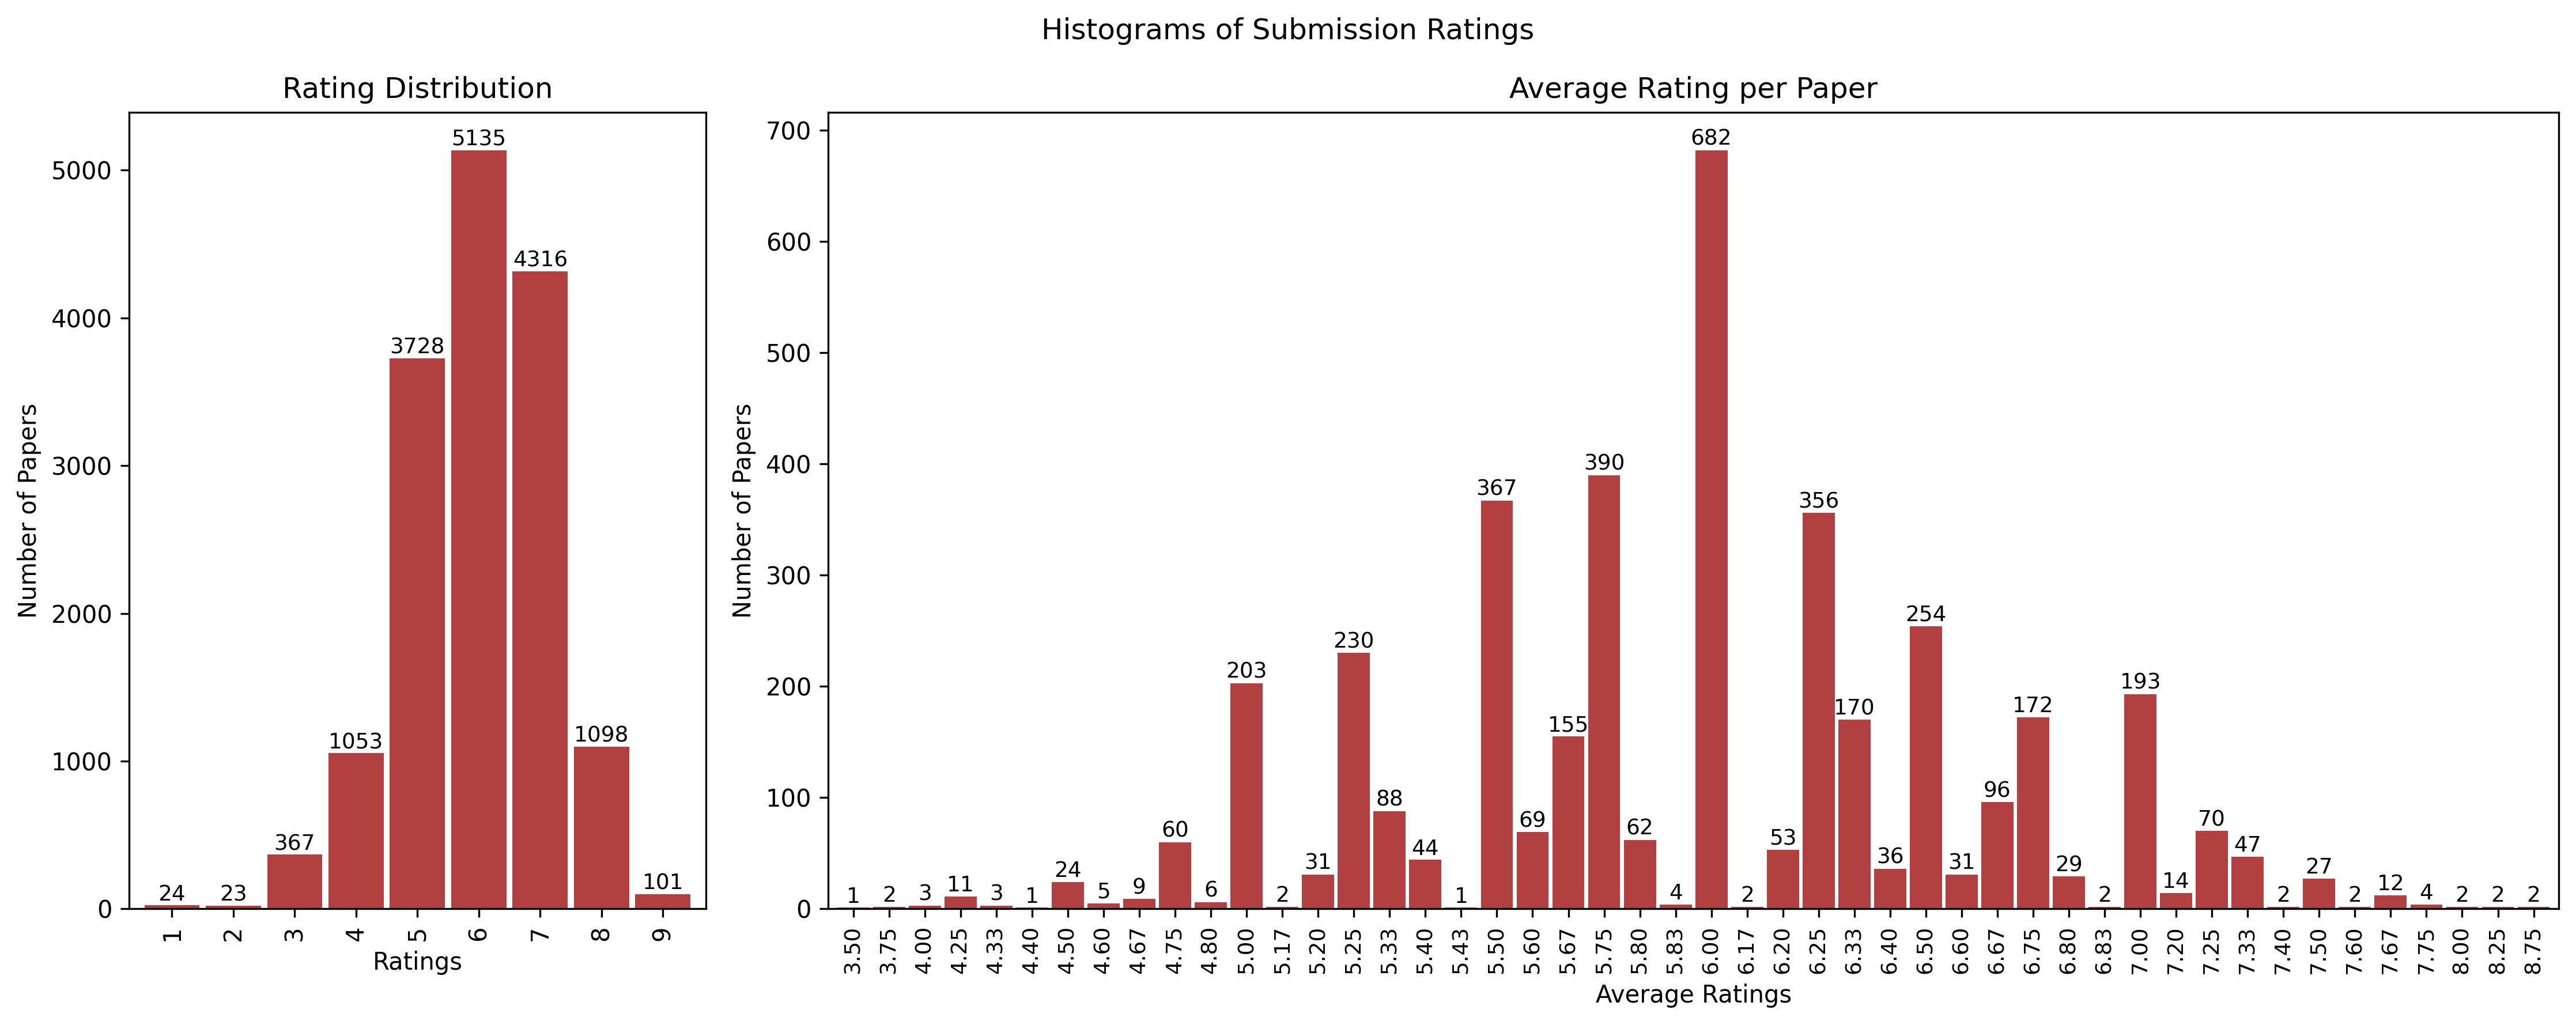

In [42]:
# 2. 数据预处理
ratings = []
average_ratings = []   # 每篇论文的平均评分

for i, rating in enumerate(all_ratings):
    
    if rating != "No Ratings":
        # 将评分字符串拆分并转换为整数
        paper_ratings = [int(rate) for rate in rating.split(', ') if rate.strip()]
        ratings.extend(paper_ratings)  # 添加到总评分列表
        
        # 计算当前论文的平均评分
        average_ratings.append(sum(paper_ratings) / len(paper_ratings))
    else:
        print(all_titles[i])
        
# 3. 绘制直方图
fig = plt.figure(figsize=(15, 6), dpi=300)
plt.suptitle('Histograms of Submission Ratings')

# 子图布局
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 3])

# 左侧子图：评分分布直方图
plt.subplot(gs[0])
rating_counter = sorted(Counter(ratings).items())  # 统计评分出现次数
x_labels = [str(k[0]) for k in rating_counter]
frequencies = [k[1] for k in rating_counter]

# 使用 Pandas 绘制柱状图
pd.Series(frequencies).plot(kind='bar', color='#990000', alpha=0.75, width=0.9)
plt.xticks(range(len(x_labels)), x_labels)
plt.xlabel("Ratings")
plt.ylabel("Number of Papers")
plt.title("Rating Distribution")

# 为每个柱子添加标签
for i, val in enumerate(frequencies):
    plt.text(i, val + 0.5, str(val), ha='center', va='bottom', fontsize=9)

# 右侧子图：每篇论文的平均评分直方图
plt.subplot(gs[1])
avg_rating_counter = sorted(Counter(average_ratings).items())  # 统计平均评分
x_labels_avg = ['{:.2f}'.format(k[0]) for k in avg_rating_counter]
frequencies_avg = [k[1] for k in avg_rating_counter]

# 使用 Pandas 绘制柱状图
pd.Series(frequencies_avg).plot(kind='bar', color='#990000', alpha=0.75, width=0.9)
plt.xticks(range(len(x_labels_avg)), x_labels_avg, fontsize=9)
plt.xlabel("Average Ratings")
plt.ylabel("Number of Papers")
plt.title("Average Rating per Paper")

# 为每个柱子添加标签
for i, val in enumerate(frequencies_avg):
    plt.text(i, val + 0.5, str(val), ha='center', va='bottom', fontsize=9)

# 显示图形
plt.tight_layout()
plt.show()

# 保存图形
if not os.path.exists(f'{path}/assets/'):
    os.mkdir(f'{path}/assets/')
fig.savefig(f'{path}/assets/rating_histograms.png')

## The cumulative sum of reviewer ratings(Reviewer评分的累积总和)

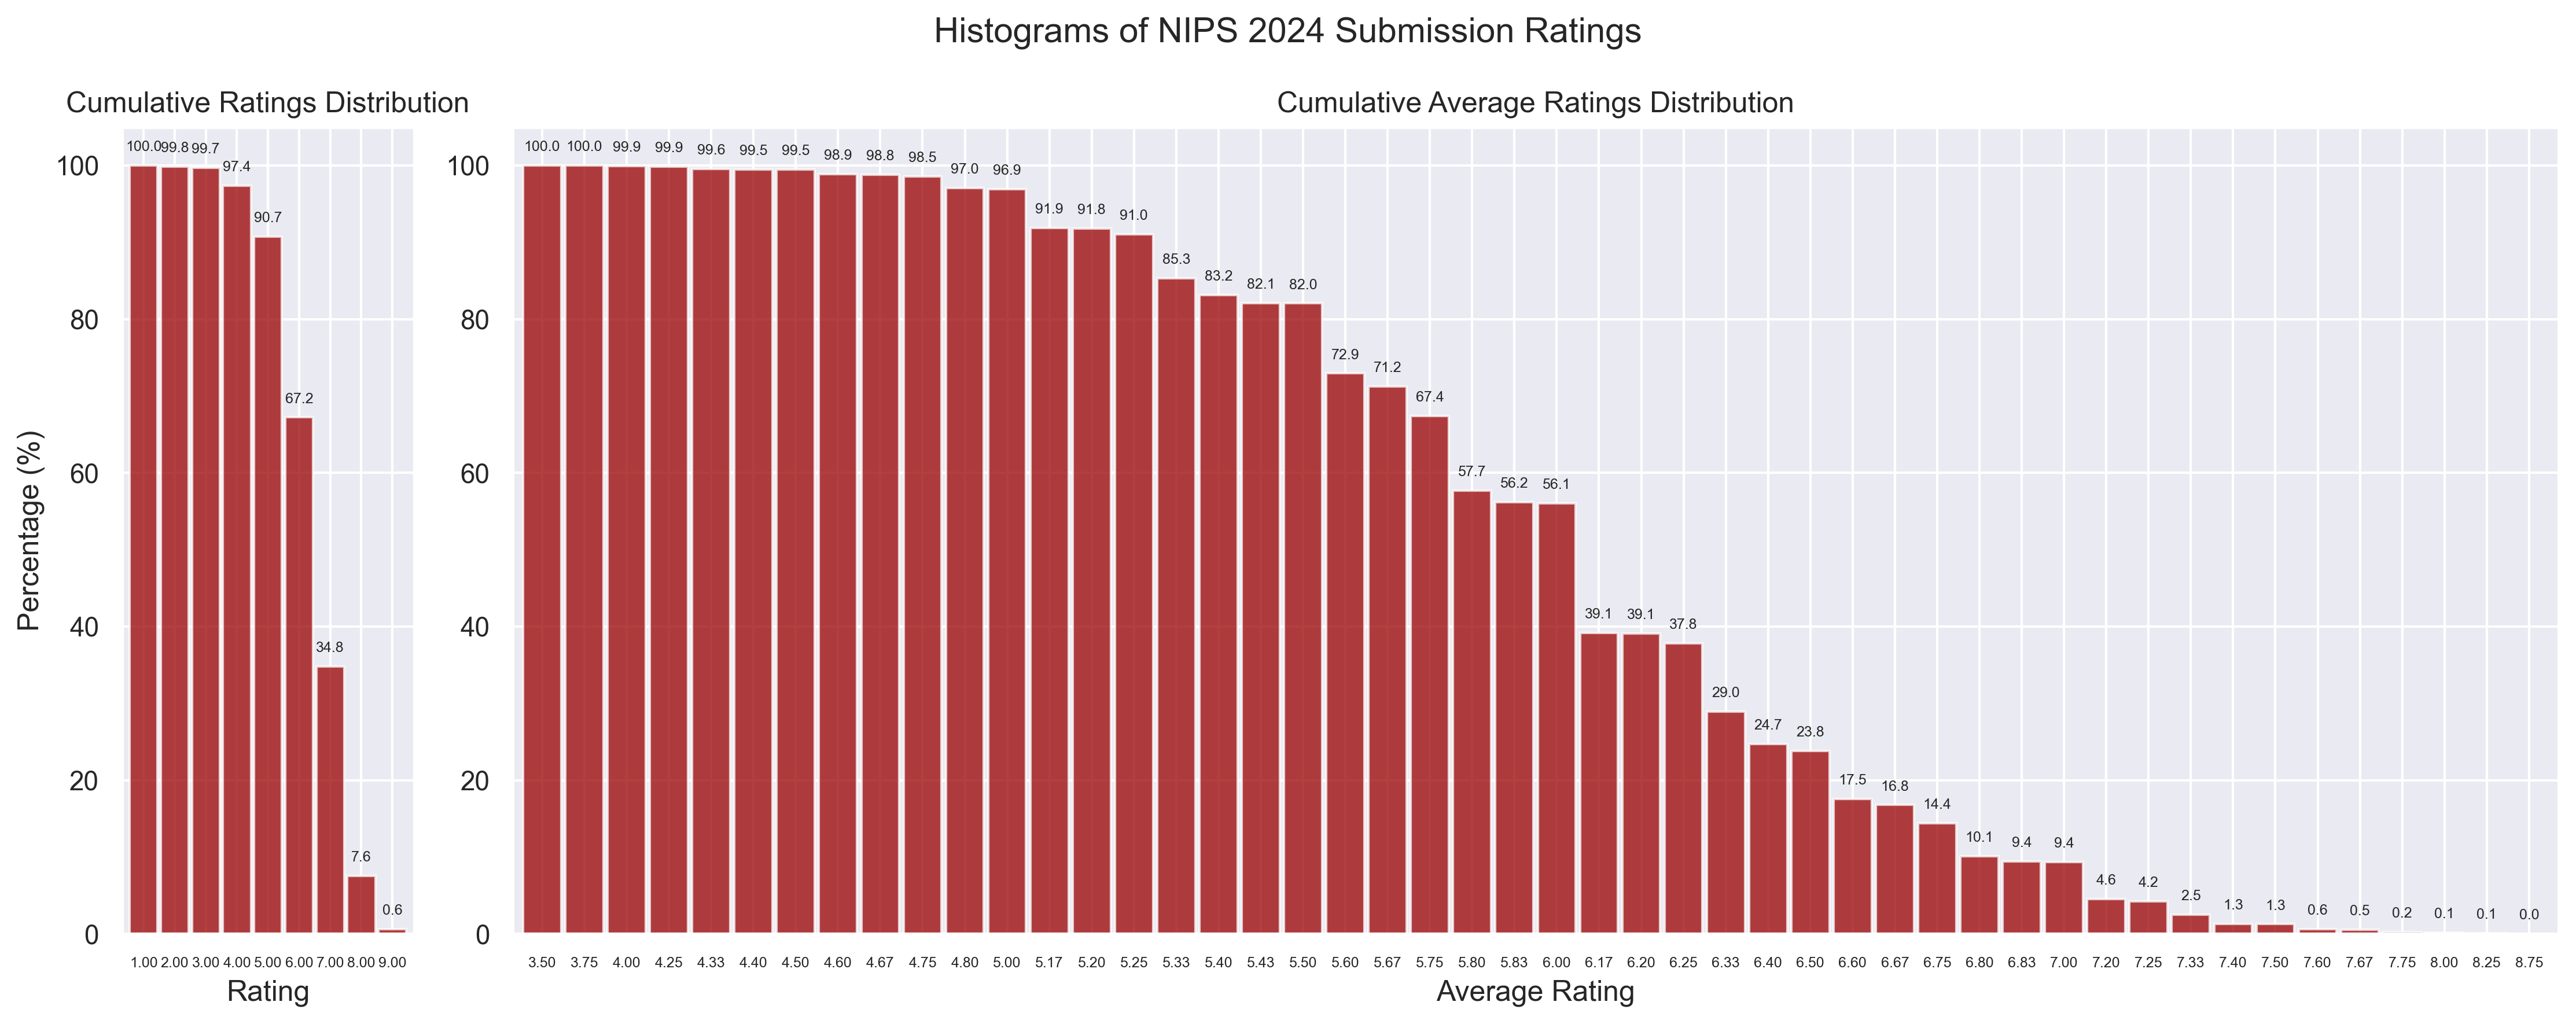

In [43]:
sns.set()  # 使用 Seaborn 样式

# 设置画布和标题
fig = plt.figure(figsize=(15, 6), dpi=300)
plt.suptitle('Histograms of NIPS 2024 Submission Ratings')

# 子图布局：左侧（评分分布），右侧（平均评分分布）
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 7])

# ===== 左侧子图：所有评分的累积百分比直方图 =====
plt.subplot(gs[0])

# 统计评分分布
rating_counter = sorted(Counter(ratings).items())  # 统计评分次数并排序
ratings = [k[0] for k in rating_counter]  # x轴：评分值
frequencies = [k[1] for k in rating_counter]  # y轴：每个评分的频率

# 计算累积百分比
total_ratings = np.sum(frequencies)
percentages = [(f / total_ratings) * 100 for f in frequencies]  # 转换为百分比
cumulative_percentages = np.cumsum(percentages[::-1])[::-1]  # 累积百分比（从高到低）

# 绘制柱状图
x_labels = ['{:.2f}'.format(r) for r in ratings]
pd.Series(cumulative_percentages).plot(kind='bar', color='#990000', alpha=0.75, width=0.9)

# 设置轴标签和标题
plt.xlabel('Rating')
plt.ylabel('Percentage (%)')
plt.title('Cumulative Ratings Distribution')
plt.xticks(range(len(x_labels)), x_labels, rotation=0, fontsize=6)

# 为柱子添加标签
for i, percentage in enumerate(cumulative_percentages):
    plt.text(i, percentage + 1.5, '{:.1f}'.format(percentage),
             ha='center', va='bottom', fontsize=6)

# ===== 右侧子图：每篇论文平均评分的累积百分比直方图 =====
plt.subplot(gs[1])

# 统计平均评分分布
avg_rating_counter = sorted(Counter(average_ratings).items())  # 统计平均评分次数并排序
avg_ratings = [k[0] for k in avg_rating_counter]  # x轴：平均评分值
frequencies_avg = [k[1] for k in avg_rating_counter]  # y轴：频率

# 计算累积百分比
total_avg_ratings = np.sum(frequencies_avg)
percentages_avg = [(f / total_avg_ratings) * 100 for f in frequencies_avg]  # 转换为百分比
cumulative_percentages_avg = np.cumsum(percentages_avg[::-1])[::-1]  # 累积百分比（从高到低）

# 绘制柱状图
x_labels_avg = ['{:.2f}'.format(r) for r in avg_ratings]
pd.Series(cumulative_percentages_avg).plot(kind='bar', color='#990000', alpha=0.75, width=0.9)

# 设置轴标签和标题
plt.xlabel('Average Rating')
plt.title('Cumulative Average Ratings Distribution')
plt.xticks(range(len(x_labels_avg)), x_labels_avg, rotation=0, fontsize=6)

# 为柱子添加标签
for i, percentage in enumerate(cumulative_percentages_avg):
    plt.text(i, percentage + 1.5, '{:.1f}'.format(percentage),
             ha='center', va='bottom', fontsize=6)

# 调整布局，展示图表并保存
plt.tight_layout()
plt.show()
fig.savefig(f'{path}/assets/rating_cumsum.png')

## 统计关键字

In [44]:
keywords = []
for i, keyword in enumerate(all_keywords):
    keywords.extend(keyword.split(', '))

print(keywords)
# Count keywords
keywords_hist = Counter(keywords)
del keywords_hist['']
print('{} different keywords before merging'.format(len(keywords_hist)))

# Merge duplicates: CNNs and CNN
duplicates = []
for k in keywords_hist:
    if k+'s' in keywords_hist:
        duplicates.append(k)
for k in duplicates:
    keywords_hist[k] += keywords_hist[k+'s']
    del keywords_hist[k+'s']
print('{} different keywords after merging'.format(len(keywords_hist)))

['Reinforcement Learning', 'Large Language Model', 'Agent', 'Retrieval Augmented Generation', 'Human Response Time', 'Preference Learning', 'Linear Bandits', 'Dueling Bandits', 'Psychology', 'Economics', 'Causality; Exchangeability', 'Continuous Multi-task Learning', 'Spatio-temporal Forecasting', 'Urban Intelligence', 'Pre-training', 'Next Token Prediction', 'Data Optimization', 'Data Selection', 'Fmri Visual Decoding; Fmri-to-video Reconstruction', 'Diffusion Models', 'Inverse Reinforcement Learning', 'Dynamic Programming', 'Reinforcement Learning', 'Generative Modeling', 'In-context Learning', 'Grokking', 'Modular Arithmetic', 'Interpretability', 'Distributional Reinforcement Learning', 'Distributional Temporal Difference Learning', 'Sample Complexity', 'Quantization', 'Large Language Models', 'Unsupervised Environment Design', 'Novelty-driven Autocurricula', 'Large Language Models', 'Surveys', 'Self-attention', 'Linear Attention', 'Efficient', 'Softmax Attention', 'Foundation Model

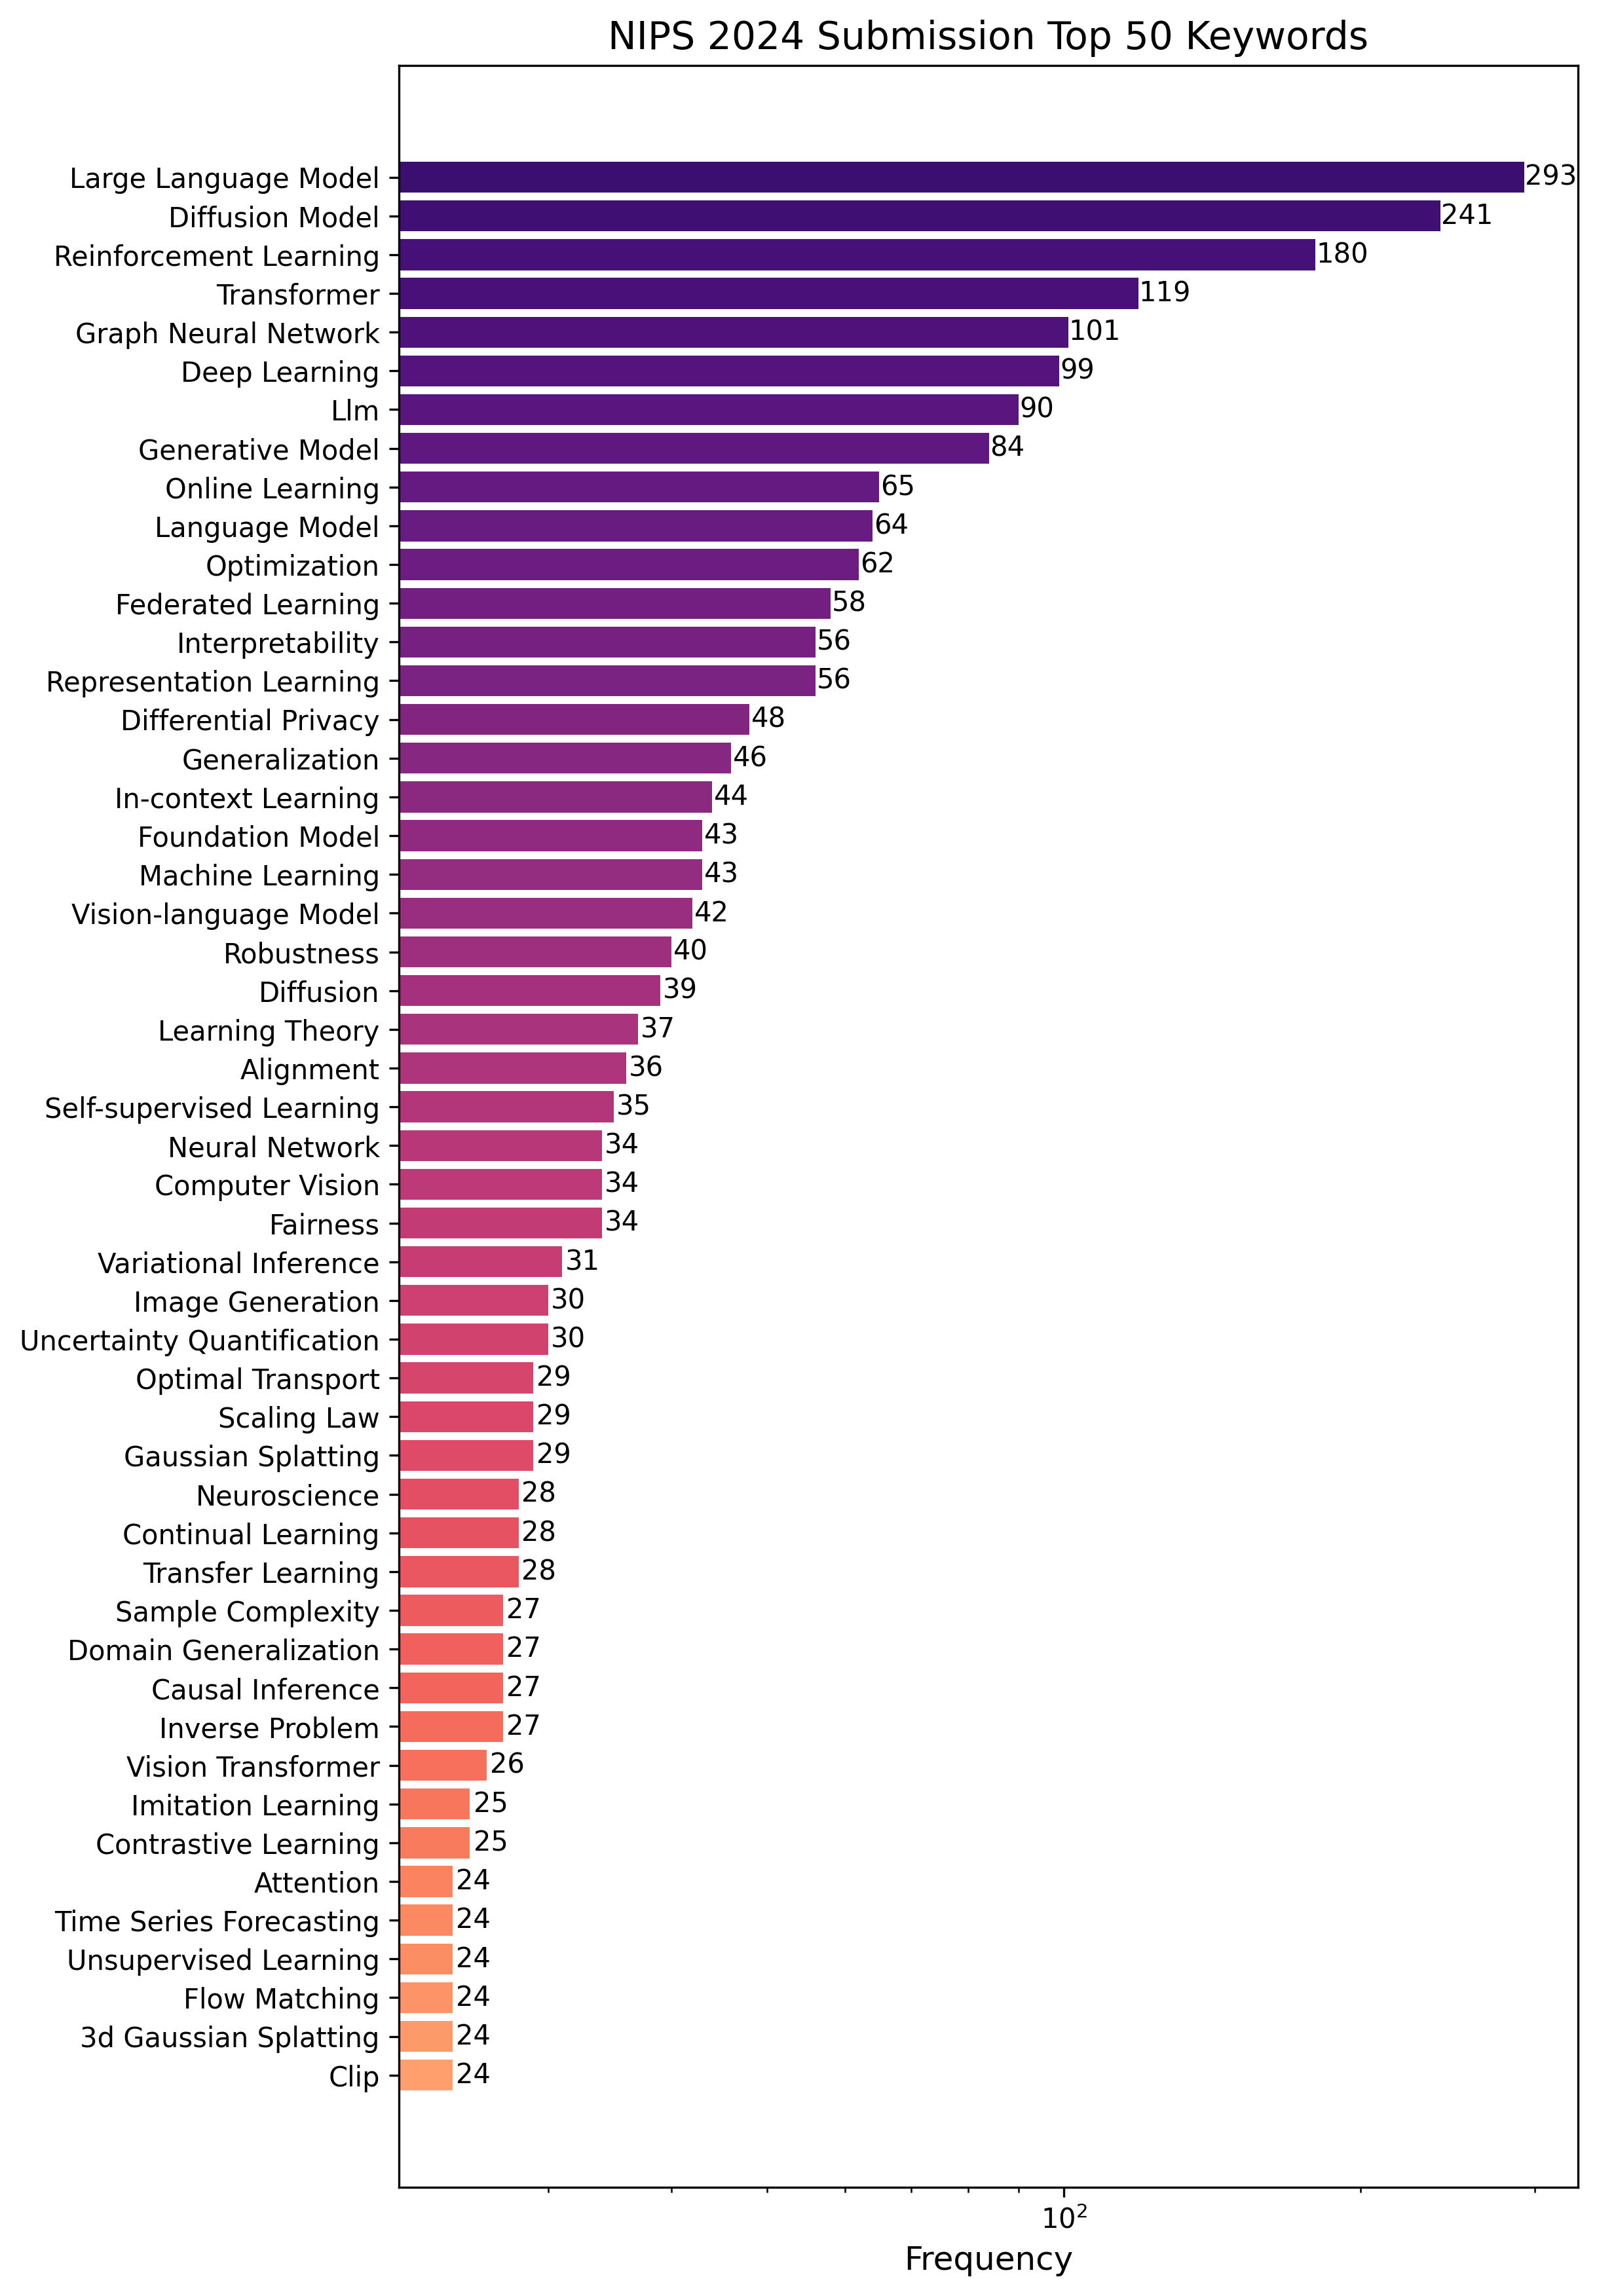

In [45]:
# 显示 N 个最常见关键词和它们的频率
num_keyword = 50
keywords_hist_vis = keywords_hist.most_common(num_keyword)

plt.rcdefaults()
fig, ax = plt.subplots(figsize=(8, 12), dpi=300)

# 数据准备
key = [k[0] for k in keywords_hist_vis]
value = [k[1] for k in keywords_hist_vis]
y_pos = np.arange(len(key))

# 使用 cool colormap 渐变颜色
colors = cm.magma(np.linspace(0.2, 0.8, len(key)))  # 渐变色

# 绘制水平条形图
bars = ax.barh(y_pos, value, align='center', color=colors, ecolor='black', log=True)
ax.set_yticks(y_pos)
ax.set_yticklabels(key, rotation=0, fontsize=10)
ax.invert_yaxis()  # 反转 Y 轴

# 为每个条形添加文本标签
for i, (bar, v) in enumerate(zip(bars, value)):
    text_position = bar.get_width() - 5  # 文字的水平位置
    ax.text(bar.get_width() + 0.2, i, str(v), color='black', ha='left', va='center', fontsize=10)

# 添加标题和标签
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('NIPS 2024 Submission Top {} Keywords'.format(num_keyword), fontsize=14)

# 调整布局，确保所有内容显示完整
plt.tight_layout()
plt.subplots_adjust(left=0.2, right=0.95, top=0.95, bottom=0.05)  # 手动调整边距

# 显示和保存图形
plt.show()
fig.savefig(f'{path}/assets/frequency.png', dpi=300, bbox_inches='tight')

## Top authors

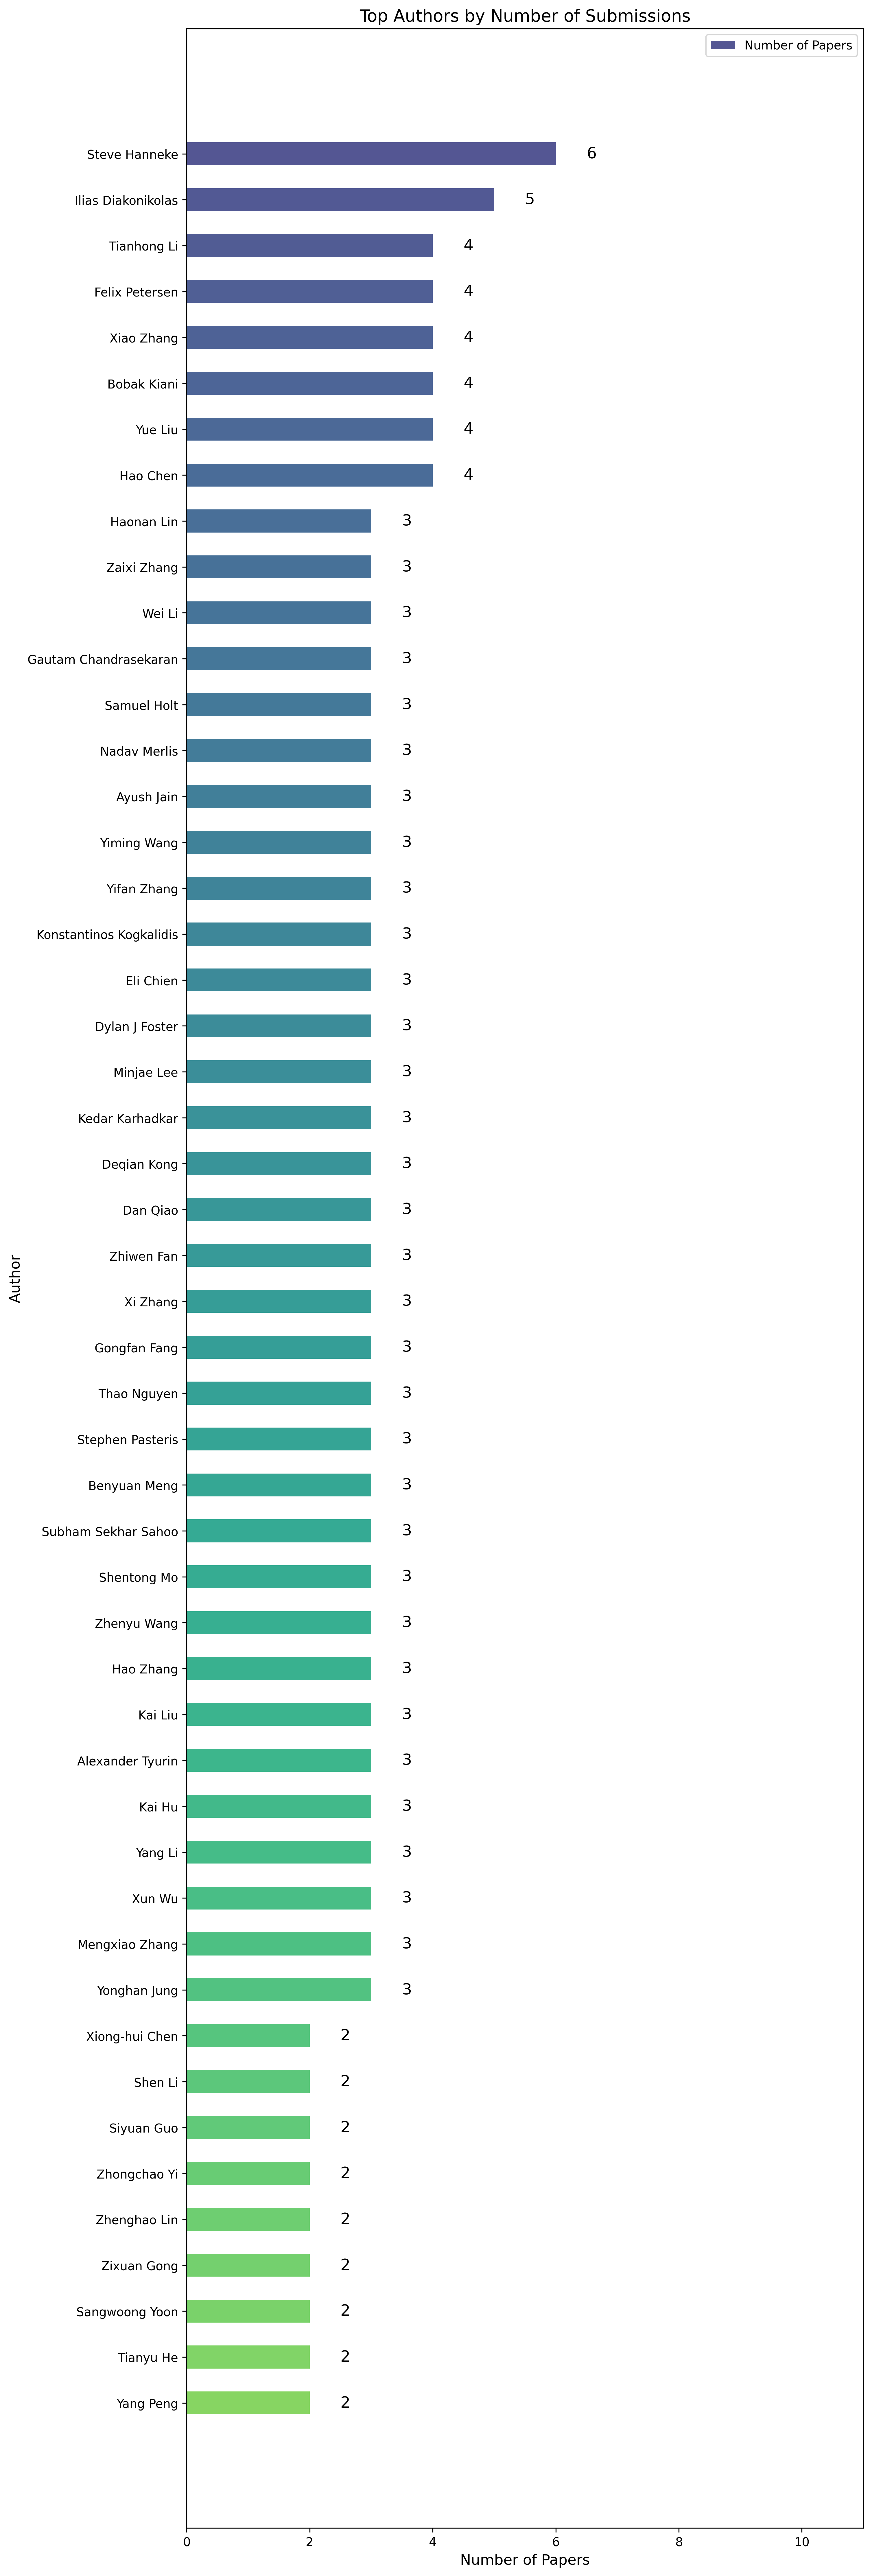

In [46]:
authors = []
N = 50  # 作者数量
first_author = True

for i, author in enumerate(all_authors):
    if first_author:
        authors.append(author.split(', ')[0])
    else:
        authors.extend(author.split(', '))
        
authors_common = Counter(authors).most_common()[:N]

authors = [ac[0] for ac in authors_common]  # 作者名
paper_counts = [ac[1] for ac in authors_common]  # 每位作者的投稿数

# 设置图形尺寸
if not first_author:
    fig, ax = plt.subplots(figsize=(12, 20), dpi=300)
else:
    fig, ax = plt.subplots(figsize=(12, 32), dpi=300)

# 创建柱状图索引
ind = np.arange(N)  # y 轴上的作者索引
width = 0.5  # 柱宽

# 使用 cool colormap 渐变颜色
colors = cm.viridis(np.linspace(0.2, 0.8, len(authors)))

# 绘制水平条形图
bars = ax.barh(ind, paper_counts, width, color=colors, alpha=0.9)

# 为每个条形添加文本标签
for i, (bar, count) in enumerate(zip(bars, paper_counts)):
    text_position = bar.get_width() - 5  # 文字的水平位置
    ax.text(bar.get_width() + 0.5, i, str(count), color='black', ha='left', va='center', fontsize=13)

# 设置图形标题和轴标签
ax.set_xlabel('Number of Papers', fontsize=12)
ax.set_title('Top Authors by Number of Submissions', fontsize=14)
plt.ylabel('Author', fontsize=12)
plt.yticks(ind, authors, fontsize=10)  # y 轴显示作者名
plt.gca().invert_yaxis()  # 反转 y 轴，保证排名从上到下

# 调整 x 轴范围
plt.xlim(0, max(paper_counts) + 5)

# 添加图例
plt.legend(['Number of Papers'], loc='best')

# 调整布局，确保所有内容显示完整
plt.tight_layout()
plt.subplots_adjust(left=0.3, right=0.95, top=0.95, bottom=0.05)

# 显示和保存图像
plt.show()
fig.savefig(f'{path}/assets/authors_submission_counts.png', dpi=300, bbox_inches='tight')

## Graph

In [47]:
prompts = ['Graph', 'GNN', 'GCN', 'GAT']

graph_index = []

for i, abstract in enumerate(all_abstracts):
    for prompt in prompts:
        if prompt in abstract or prompt in all_titles[i] or prompt in all_keywords[i]:
            graph_index.append(i)
            break
          
            

In [48]:
# 存储匹配的论文数据
data_to_save = []
graph_titles = []
for i in graph_index:
    title = all_titles[i]
    authors = all_authors[i]
    abstract = all_abstracts[i]
    keywords = all_keywords[i]
    ratings = all_ratings[i]
    confidences = all_confidences[i]
    
    graph_titles.append(title)
    
    # 构建数据字典
    data = {
        "Title": title,
        "Authors": authors,
        "Abstract": abstract,
        "Keywords": keywords,
        "Ratings": ratings,
        "Confidences": confidences
    }
    data_to_save.append(data)

# 将数据保存到 CSV 文件
fieldnames = ["Title", "Authors", "Abstract", "Keywords", "Ratings", "Confidences"]

with open(f'{path}/graph_informations.csv', mode='w', encoding='utf-8', newline='') as file:
    writer = csv.DictWriter(file, fieldnames=fieldnames)
    
    # 写入数据行
    writer.writerows(data_to_save)

print("Data saved to graph_papers.csv")

with open(f'{path}/graph_titles.csv', mode='w', encoding='utf-8', newline='') as file:
    writer = csv.writer(file)
    
    # 写入标题行
    writer.writerow(["Title"])
    
    # 写入数据行
    for title in graph_titles:
        writer.writerow([title])

print("Graph titles saved to graph_titles.csv")

Data saved to graph_papers.csv
Graph titles saved to graph_titles.csv


In [49]:
data = []
all_titles = []
all_authors = []
all_abstracts = []
all_keywords = []
all_ratings = []
all_confidences = []

direction = 'graph'
# 手动定义列名
fieldnames = ["Title", "Authors", "Abstract", "Keywords", "Ratings", "Confidences"]

# 打开并读取 CSV 文件
with open(f'{path}/graph_informations.csv', mode='r', encoding='utf-8') as file:
    reader = csv.DictReader(file, fieldnames=fieldnames)
    
    # 遍历每一行
    for row in reader:
        entry = {
            "Title": row["Title"],
            "Authors": row["Authors"],
            "Abstract": row["Abstract"],
            "Keywords": row["Keywords"],
            "Ratings": row["Ratings"],
            "Confidences": row["Confidences"]
        }
        
        all_titles.append(row["Title"])
        all_authors.append(row["Authors"])
        all_abstracts.append(row["Abstract"])
        all_keywords.append(row["Keywords"])
        all_ratings.append(row["Ratings"])
        all_confidences.append(row["Confidences"])
        
        data.append(entry)

## Graph Rating distribution(评分分布)

Learning Linear Causal Representations From General Environments: Identifiability And Intrinsic Ambiguity
Sample Complexity Of Interventional Causal Representation Learning


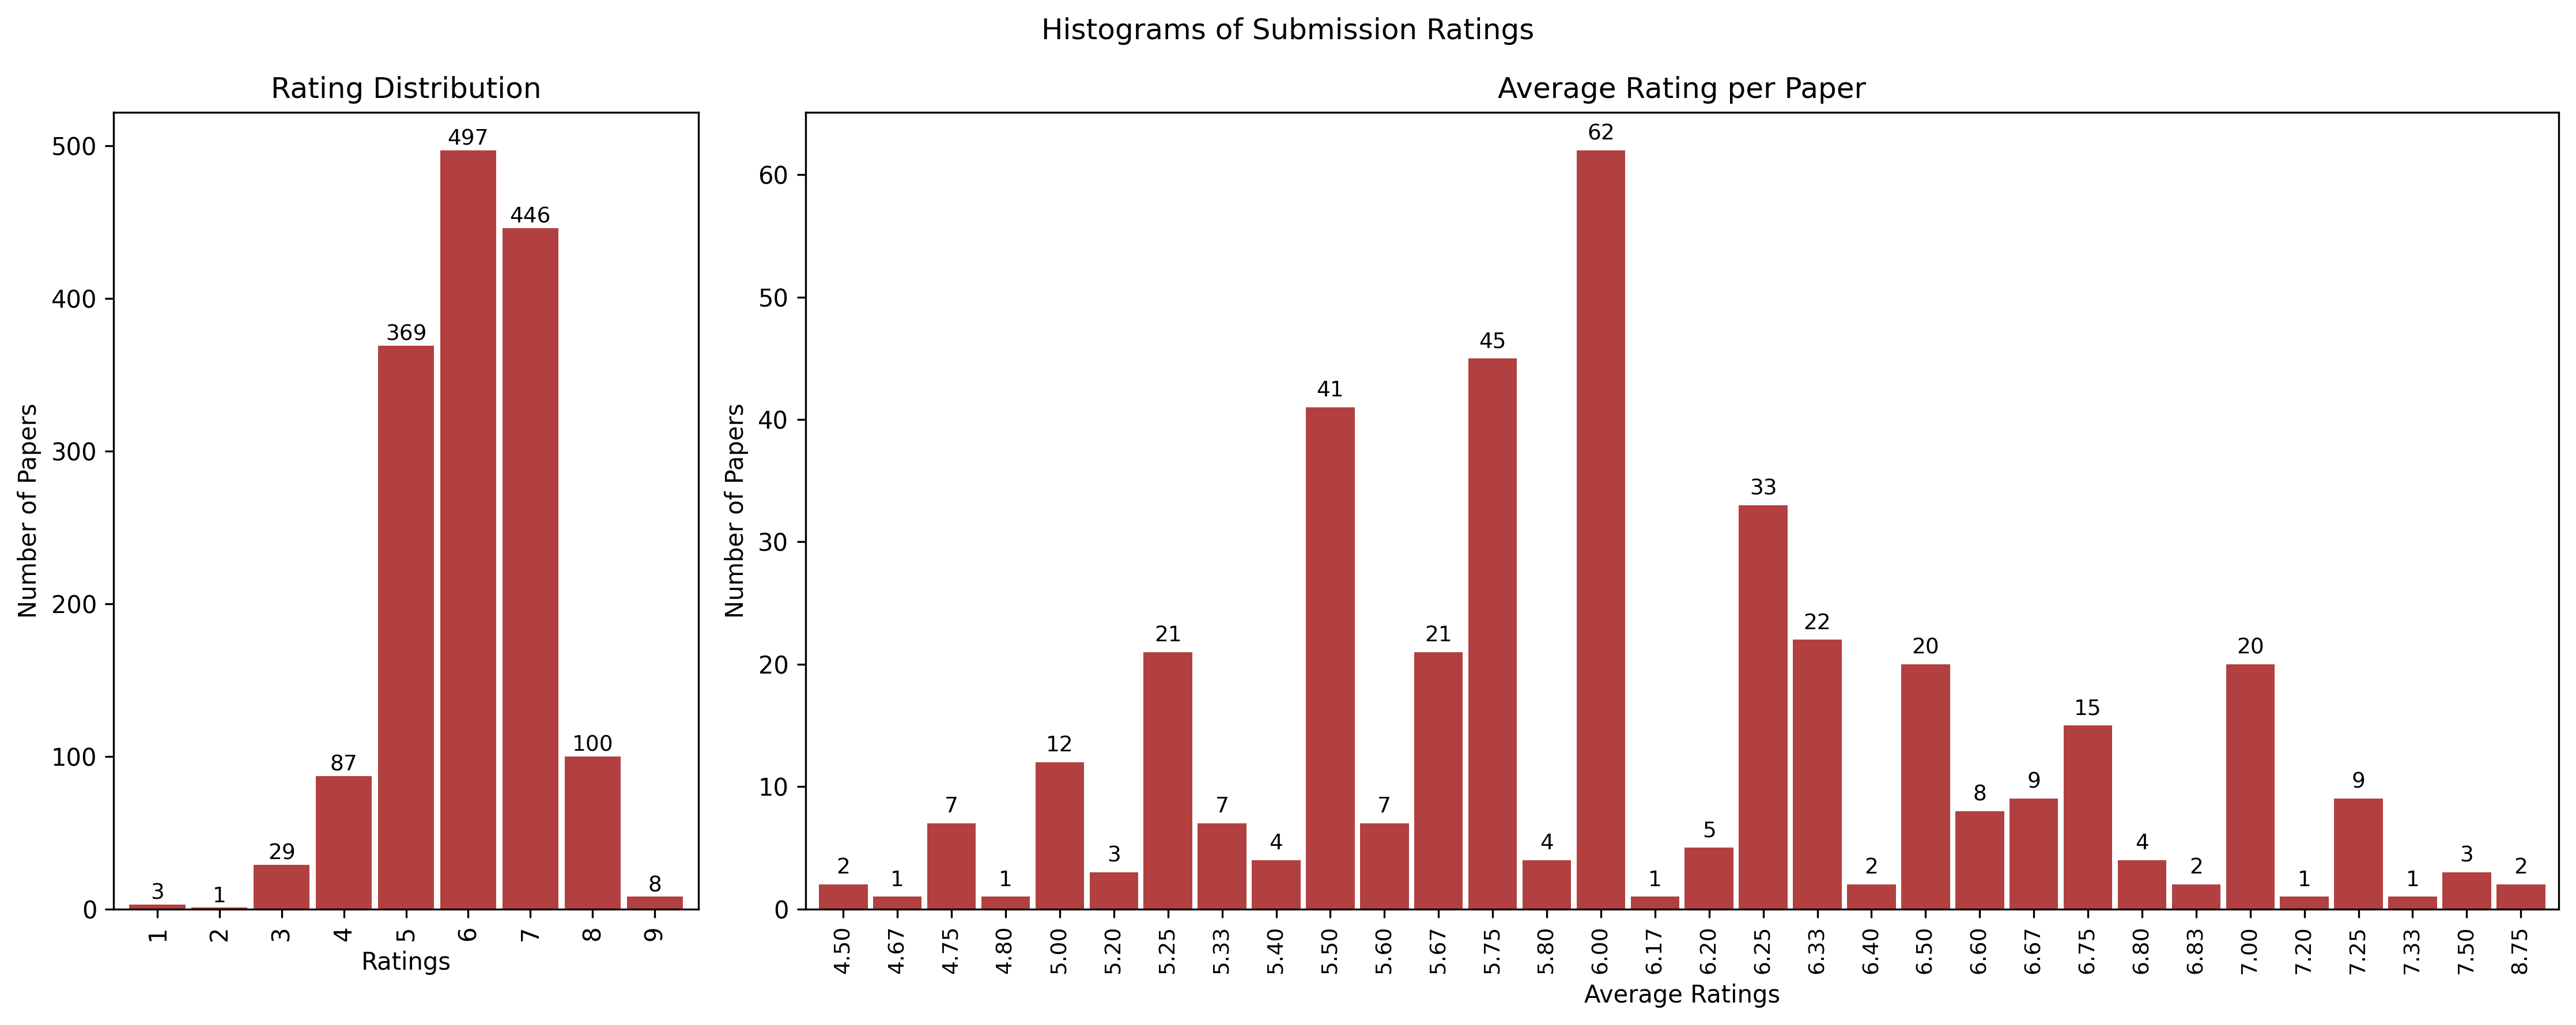

In [50]:
# 2. 数据预处理
ratings = []
average_ratings = []   # 每篇论文的平均评分

for i, rating in enumerate(all_ratings):
    
    if rating != "No Ratings":
        # 将评分字符串拆分并转换为整数
        paper_ratings = [int(rate) for rate in rating.split(', ') if rate.strip()]
        ratings.extend(paper_ratings)  # 添加到总评分列表
        
        # 计算当前论文的平均评分
        average_ratings.append(sum(paper_ratings) / len(paper_ratings))
    else:
        print(all_titles[i])
        
# 3. 绘制直方图
fig = plt.figure(figsize=(15, 6), dpi=300)
plt.suptitle('Histograms of Submission Ratings')

# 子图布局
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 3])

# 左侧子图：评分分布直方图
plt.subplot(gs[0])
rating_counter = sorted(Counter(ratings).items())  # 统计评分出现次数
x_labels = [str(k[0]) for k in rating_counter]
frequencies = [k[1] for k in rating_counter]

# 使用 Pandas 绘制柱状图
pd.Series(frequencies).plot(kind='bar', color='#990000', alpha=0.75, width=0.9)
plt.xticks(range(len(x_labels)), x_labels)
plt.xlabel("Ratings")
plt.ylabel("Number of Papers")
plt.title("Rating Distribution")

# 为每个柱子添加标签
for i, val in enumerate(frequencies):
    plt.text(i, val + 0.5, str(val), ha='center', va='bottom', fontsize=9)

# 右侧子图：每篇论文的平均评分直方图
plt.subplot(gs[1])
avg_rating_counter = sorted(Counter(average_ratings).items())  # 统计平均评分
x_labels_avg = ['{:.2f}'.format(k[0]) for k in avg_rating_counter]
frequencies_avg = [k[1] for k in avg_rating_counter]

# 使用 Pandas 绘制柱状图
pd.Series(frequencies_avg).plot(kind='bar', color='#990000', alpha=0.75, width=0.9)
plt.xticks(range(len(x_labels_avg)), x_labels_avg, fontsize=9)
plt.xlabel("Average Ratings")
plt.ylabel("Number of Papers")
plt.title("Average Rating per Paper")

# 为每个柱子添加标签
for i, val in enumerate(frequencies_avg):
    plt.text(i, val + 0.5, str(val), ha='center', va='bottom', fontsize=9)

# 显示图形
plt.tight_layout()
plt.show()

# 保存图形
fig.savefig(f'{path}/assets/graph_rating_histograms.png')

## The cumulative sum of reviewer ratings(Reviewer评分的累积总和)

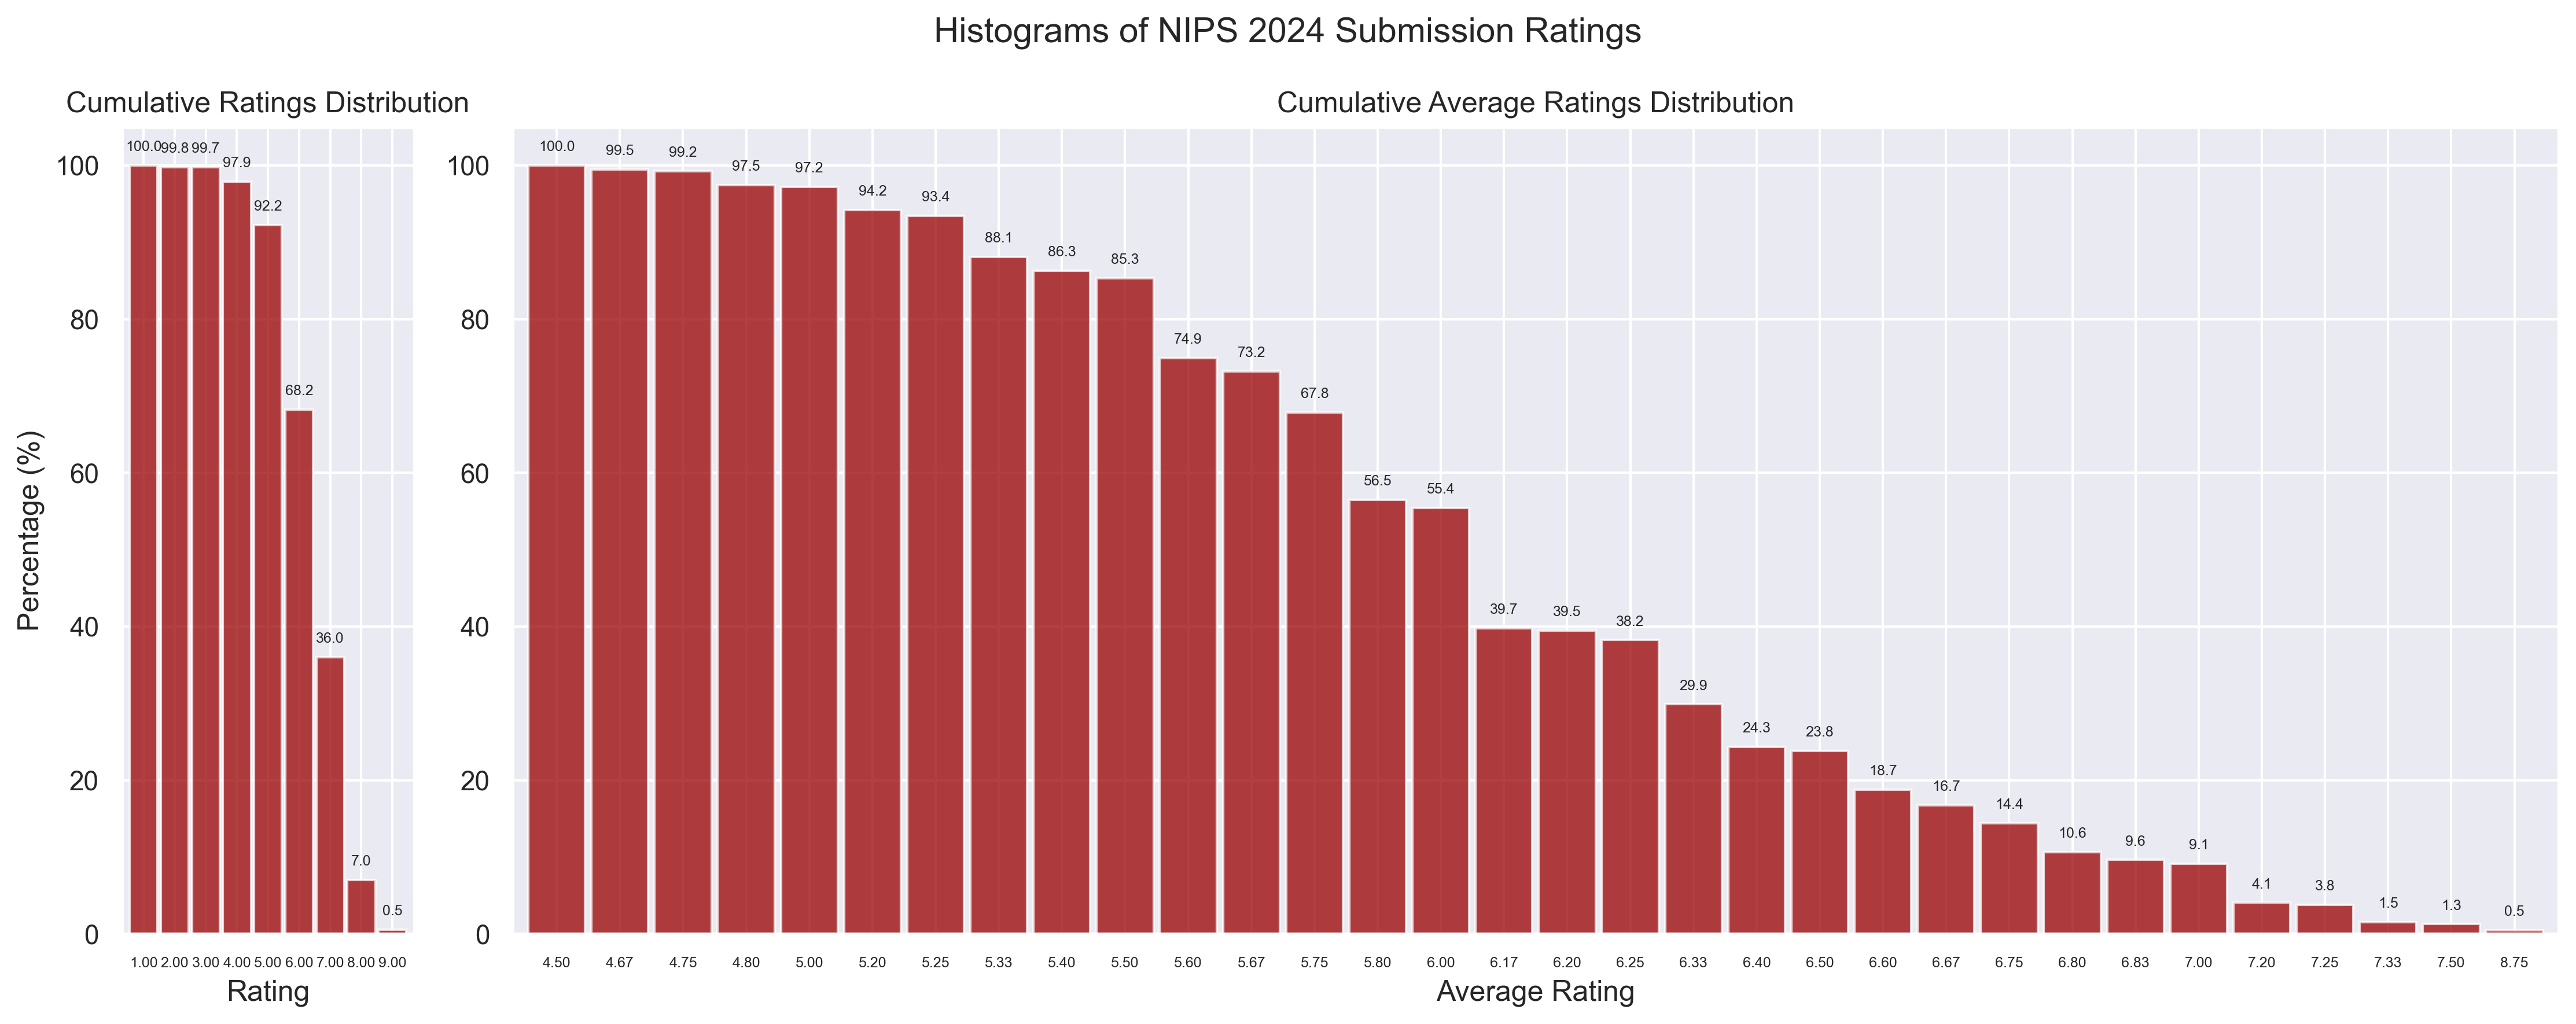

In [51]:
sns.set()  # 使用 Seaborn 样式

# 设置画布和标题
fig = plt.figure(figsize=(15, 6), dpi=300)
plt.suptitle('Histograms of NIPS 2024 Submission Ratings')

# 子图布局：左侧（评分分布），右侧（平均评分分布）
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 7])

# ===== 左侧子图：所有评分的累积百分比直方图 =====
plt.subplot(gs[0])

# 统计评分分布
rating_counter = sorted(Counter(ratings).items())  # 统计评分次数并排序
ratings = [k[0] for k in rating_counter]  # x轴：评分值
frequencies = [k[1] for k in rating_counter]  # y轴：每个评分的频率

# 计算累积百分比
total_ratings = np.sum(frequencies)
percentages = [(f / total_ratings) * 100 for f in frequencies]  # 转换为百分比
cumulative_percentages = np.cumsum(percentages[::-1])[::-1]  # 累积百分比（从高到低）

# 绘制柱状图
x_labels = ['{:.2f}'.format(r) for r in ratings]
pd.Series(cumulative_percentages).plot(kind='bar', color='#990000', alpha=0.75, width=0.9)

# 设置轴标签和标题
plt.xlabel('Rating')
plt.ylabel('Percentage (%)')
plt.title('Cumulative Ratings Distribution')
plt.xticks(range(len(x_labels)), x_labels, rotation=0, fontsize=6)

# 为柱子添加标签
for i, percentage in enumerate(cumulative_percentages):
    plt.text(i, percentage + 1.5, '{:.1f}'.format(percentage),
             ha='center', va='bottom', fontsize=6)

# ===== 右侧子图：每篇论文平均评分的累积百分比直方图 =====
plt.subplot(gs[1])

# 统计平均评分分布
avg_rating_counter = sorted(Counter(average_ratings).items())  # 统计平均评分次数并排序
avg_ratings = [k[0] for k in avg_rating_counter]  # x轴：平均评分值
frequencies_avg = [k[1] for k in avg_rating_counter]  # y轴：频率

# 计算累积百分比
total_avg_ratings = np.sum(frequencies_avg)
percentages_avg = [(f / total_avg_ratings) * 100 for f in frequencies_avg]  # 转换为百分比
cumulative_percentages_avg = np.cumsum(percentages_avg[::-1])[::-1]  # 累积百分比（从高到低）

# 绘制柱状图
x_labels_avg = ['{:.2f}'.format(r) for r in avg_ratings]
pd.Series(cumulative_percentages_avg).plot(kind='bar', color='#990000', alpha=0.75, width=0.9)

# 设置轴标签和标题
plt.xlabel('Average Rating')
plt.title('Cumulative Average Ratings Distribution')
plt.xticks(range(len(x_labels_avg)), x_labels_avg, rotation=0, fontsize=6)

# 为柱子添加标签
for i, percentage in enumerate(cumulative_percentages_avg):
    plt.text(i, percentage + 1.5, '{:.1f}'.format(percentage),
             ha='center', va='bottom', fontsize=6)

# 调整布局，展示图表并保存
plt.tight_layout()
plt.show()
fig.savefig(f'{path}/assets/graph_rating_cumsum.png')

## 统计关键字

In [52]:
keywords = []
for i, keyword in enumerate(all_keywords):
    keywords.extend(keyword.split(', '))

print(keywords)
# Count keywords
keywords_hist = Counter(keywords)
del keywords_hist['']
print('{} different keywords before merging'.format(len(keywords_hist)))

# Merge duplicates: CNNs and CNN
duplicates = []
for k in keywords_hist:
    if k+'s' in keywords_hist:
        duplicates.append(k)
for k in duplicates:
    keywords_hist[k] += keywords_hist[k+'s']
    del keywords_hist[k+'s']
print('{} different keywords after merging'.format(len(keywords_hist)))

['Graph Neural Networks', 'Weisfeiler-leman (wl) Test', 'Homomorphism Counting', 'Theory And Expressivity In Gnns', 'Cactus Graphs', 'Graph Neural Networks', 'Weight Space Networks', 'Implicit Neural Representations', 'Symmetries', 'Reasoning Tree', 'Large Language Models', 'Question Decomposition', 'Rationale Updating', 'Ai For Science', 'Automatic Differentiation', 'Deep Learning', 'Randomization', 'Graph Contrastive Learning', 'Graph Networks', 'Learned Simulation', 'Physics', 'Rigid Body Simulation', 'Scaling', 'Graph Diffusion Transformers', 'Inverse Molecular Design', 'Molecular Generation', 'Polymer Generation', 'Graph Neural Network', 'Uncertainty Estimation', 'Epistemic Uncertainty', 'Energy-based Model', 'Emergent Albedos', 'Latent Intrinsics', 'Relighting', 'Unsupervised Learning', 'Intrinsic Images', 'Cell Ontology Graph+transcriptome Foundation Model+large-scale Pre-training+cell Representation Learning+single Cell Rna Sequencing Data', 'Reinforcement Learning', 'Automatic

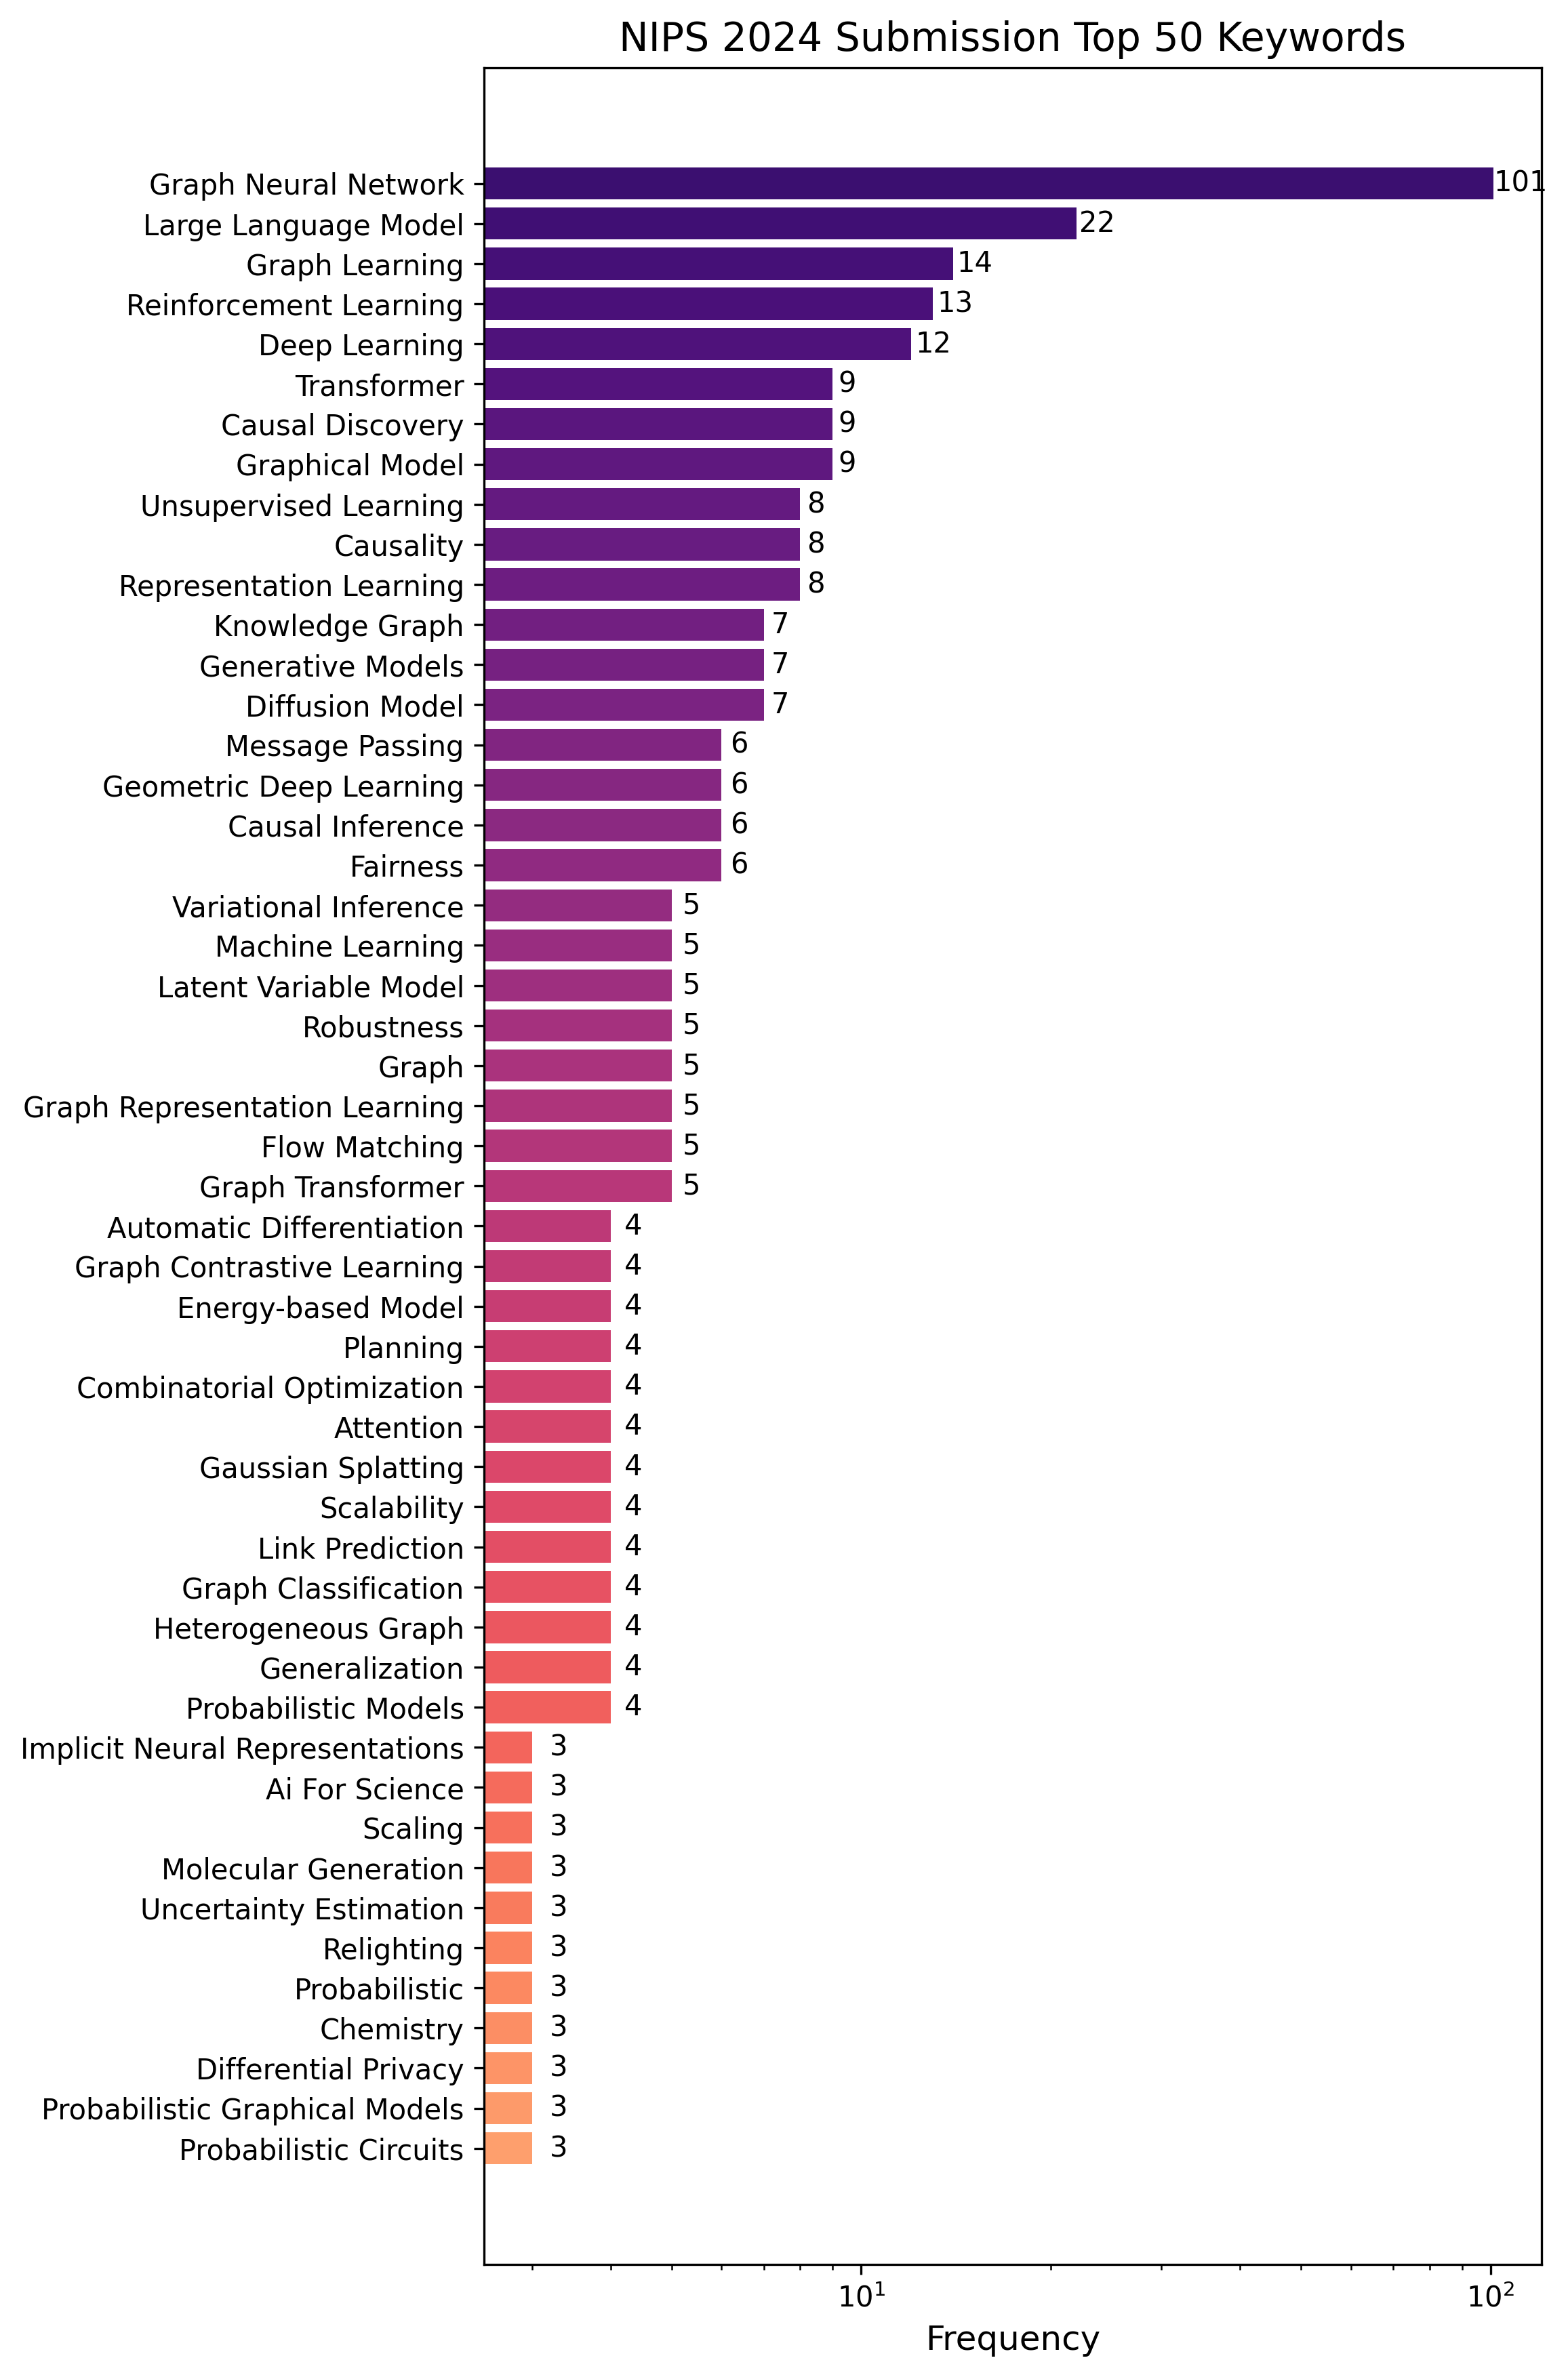

In [53]:
# 显示 N 个最常见关键词和它们的频率
num_keyword = 50
keywords_hist_vis = keywords_hist.most_common(num_keyword)

plt.rcdefaults()
fig, ax = plt.subplots(figsize=(8, 12), dpi=300)

# 数据准备
key = [k[0] for k in keywords_hist_vis]
value = [k[1] for k in keywords_hist_vis]
y_pos = np.arange(len(key))

# 使用 cool colormap 渐变颜色
colors = cm.magma(np.linspace(0.2, 0.8, len(key)))  # 渐变色

# 绘制水平条形图
bars = ax.barh(y_pos, value, align='center', color=colors, ecolor='black', log=True)
ax.set_yticks(y_pos)
ax.set_yticklabels(key, rotation=0, fontsize=10)
ax.invert_yaxis()  # 反转 Y 轴

# 为每个条形添加文本标签
for i, (bar, v) in enumerate(zip(bars, value)):
    text_position = bar.get_width() - 5  # 文字的水平位置
    ax.text(bar.get_width() + 0.2, i, str(v), color='black', ha='left', va='center', fontsize=10)

# 添加标题和标签
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('NIPS 2024 Submission Top {} Keywords'.format(num_keyword), fontsize=14)

# 调整布局，确保所有内容显示完整
plt.tight_layout()
plt.subplots_adjust(left=0.3, right=0.95, top=0.95, bottom=0.05)  # 手动调整边距

# 显示和保存图形
plt.show()
fig.savefig(f'{path}/assets/graph_frequency.png', dpi=300, bbox_inches='tight')

## Graph Authors

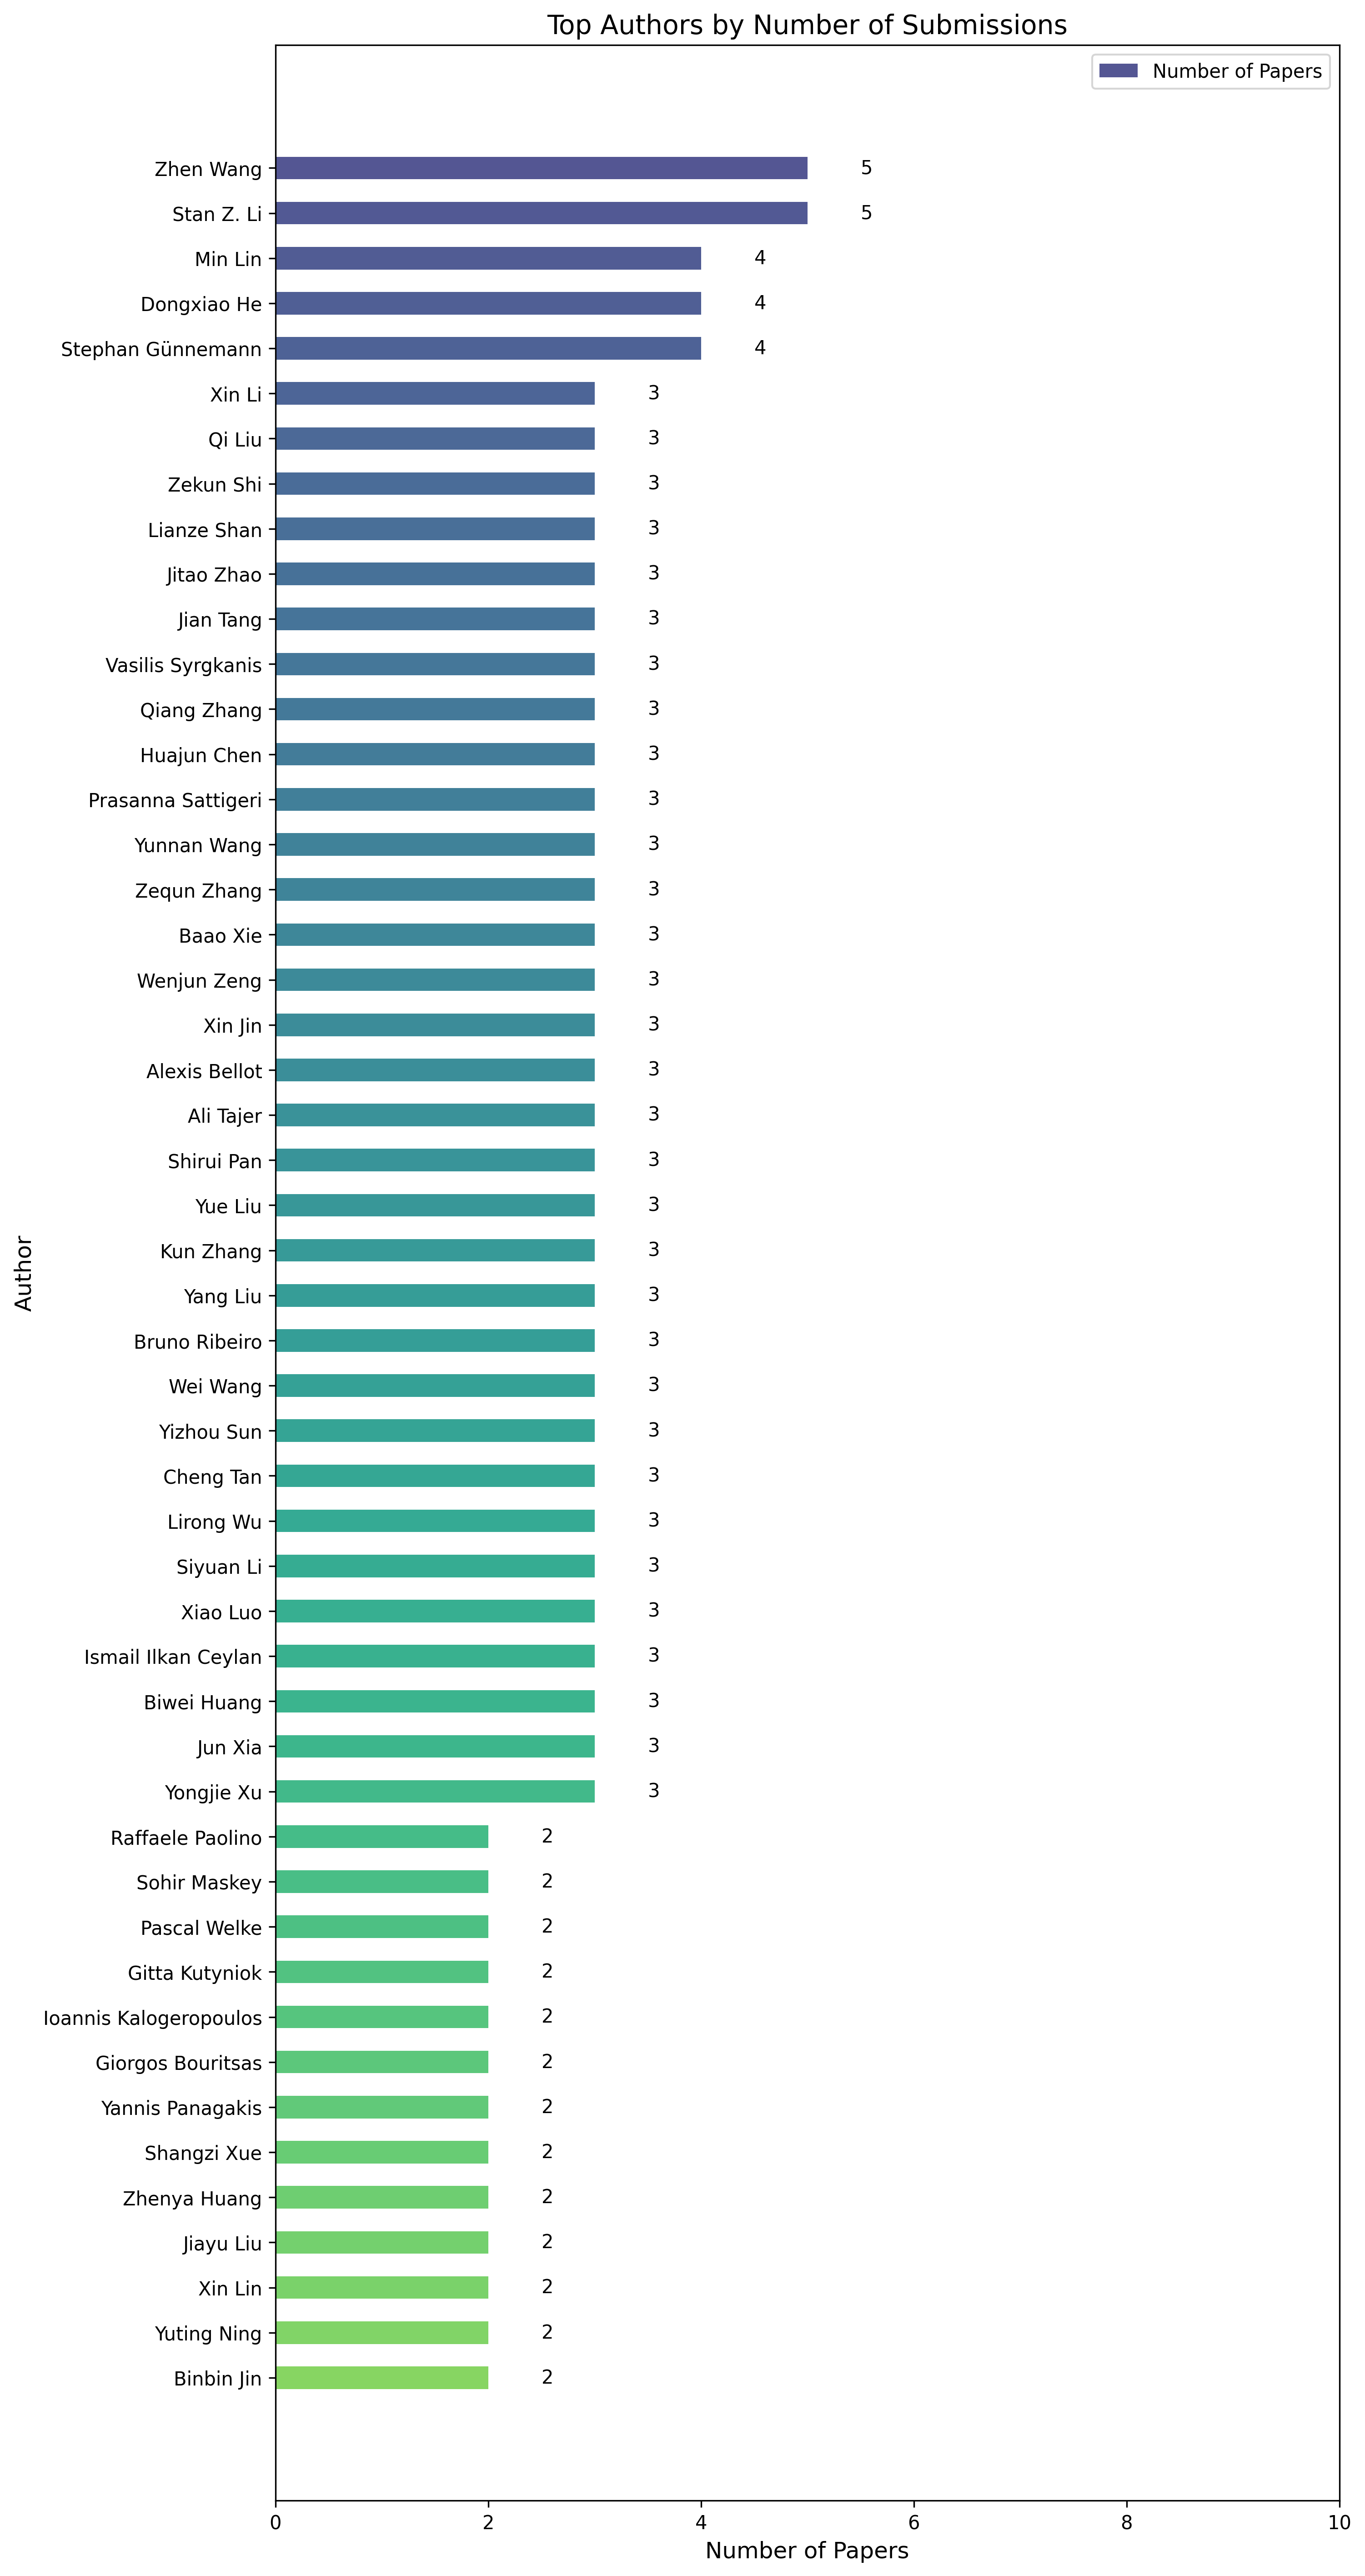

In [54]:
authors = []
N = 50  # 作者数量
first_author = False

for i, author in enumerate(all_authors):
    if first_author:
        authors.append(author.split(', ')[0])
    else:
        authors.extend(author.split(', '))
        
authors_common = Counter(authors).most_common()[:N]

authors = [ac[0] for ac in authors_common]  # 作者名
paper_counts = [ac[1] for ac in authors_common]  # 每位作者的投稿数

# 设置图形尺寸
if not first_author:
    fig, ax = plt.subplots(figsize=(12, 20), dpi=300)
else:
    fig, ax = plt.subplots(figsize=(12, 32), dpi=300)

# 创建柱状图索引
ind = np.arange(N)  # y 轴上的作者索引
width = 0.5  # 柱宽

# 使用 cool colormap 渐变颜色
colors = cm.viridis(np.linspace(0.2, 0.8, len(authors)))

# 绘制水平条形图
bars = ax.barh(ind, paper_counts, width, color=colors, alpha=0.9)

# 为每个条形添加文本标签
for i, (bar, count) in enumerate(zip(bars, paper_counts)):
    text_position = bar.get_width() - 5  # 文字的水平位置
    if text_position > 20:  # 若条形过长，文字显示在条形内部
        ax.text(text_position, i, str(count), color='white', ha='right', va='center', fontsize=10)
    else:  # 若条形过短，文字显示在条形外部
        ax.text(bar.get_width() + 0.5, i, str(count), color='black', ha='left', va='center', fontsize=10)

# 设置图形标题和轴标签
ax.set_xlabel('Number of Papers', fontsize=12)
ax.set_title('Top Authors by Number of Submissions', fontsize=14)
plt.ylabel('Author', fontsize=12)
plt.yticks(ind, authors, fontsize=10)  # y 轴显示作者名
plt.gca().invert_yaxis()  # 反转 y 轴，保证排名从上到下

# 调整 x 轴范围
plt.xlim(0, max(paper_counts) + 5)

# 添加图例
plt.legend(['Number of Papers'], loc='best')

# 调整布局，确保所有内容显示完整
plt.tight_layout()
plt.subplots_adjust(left=0.3, right=0.95, top=0.95, bottom=0.05)

# 显示和保存图像
plt.show()
fig.savefig(f'{path}/assets/graph_authors_submission_counts.png', dpi=300, bbox_inches='tight')

## 提取题目关键字

In [58]:
title_words = []
stop_words = {'of', 'for', 'and', 'the', 'a', 'to', 'in', 'on', 'at', 'by', 'with', 'as', 'from', 'is'}
for i, title in enumerate(all_titles):
    words = title.split(' ')
    filtered_words = [word for word in words if word.lower() not in stop_words]
    title_words.extend(filtered_words)

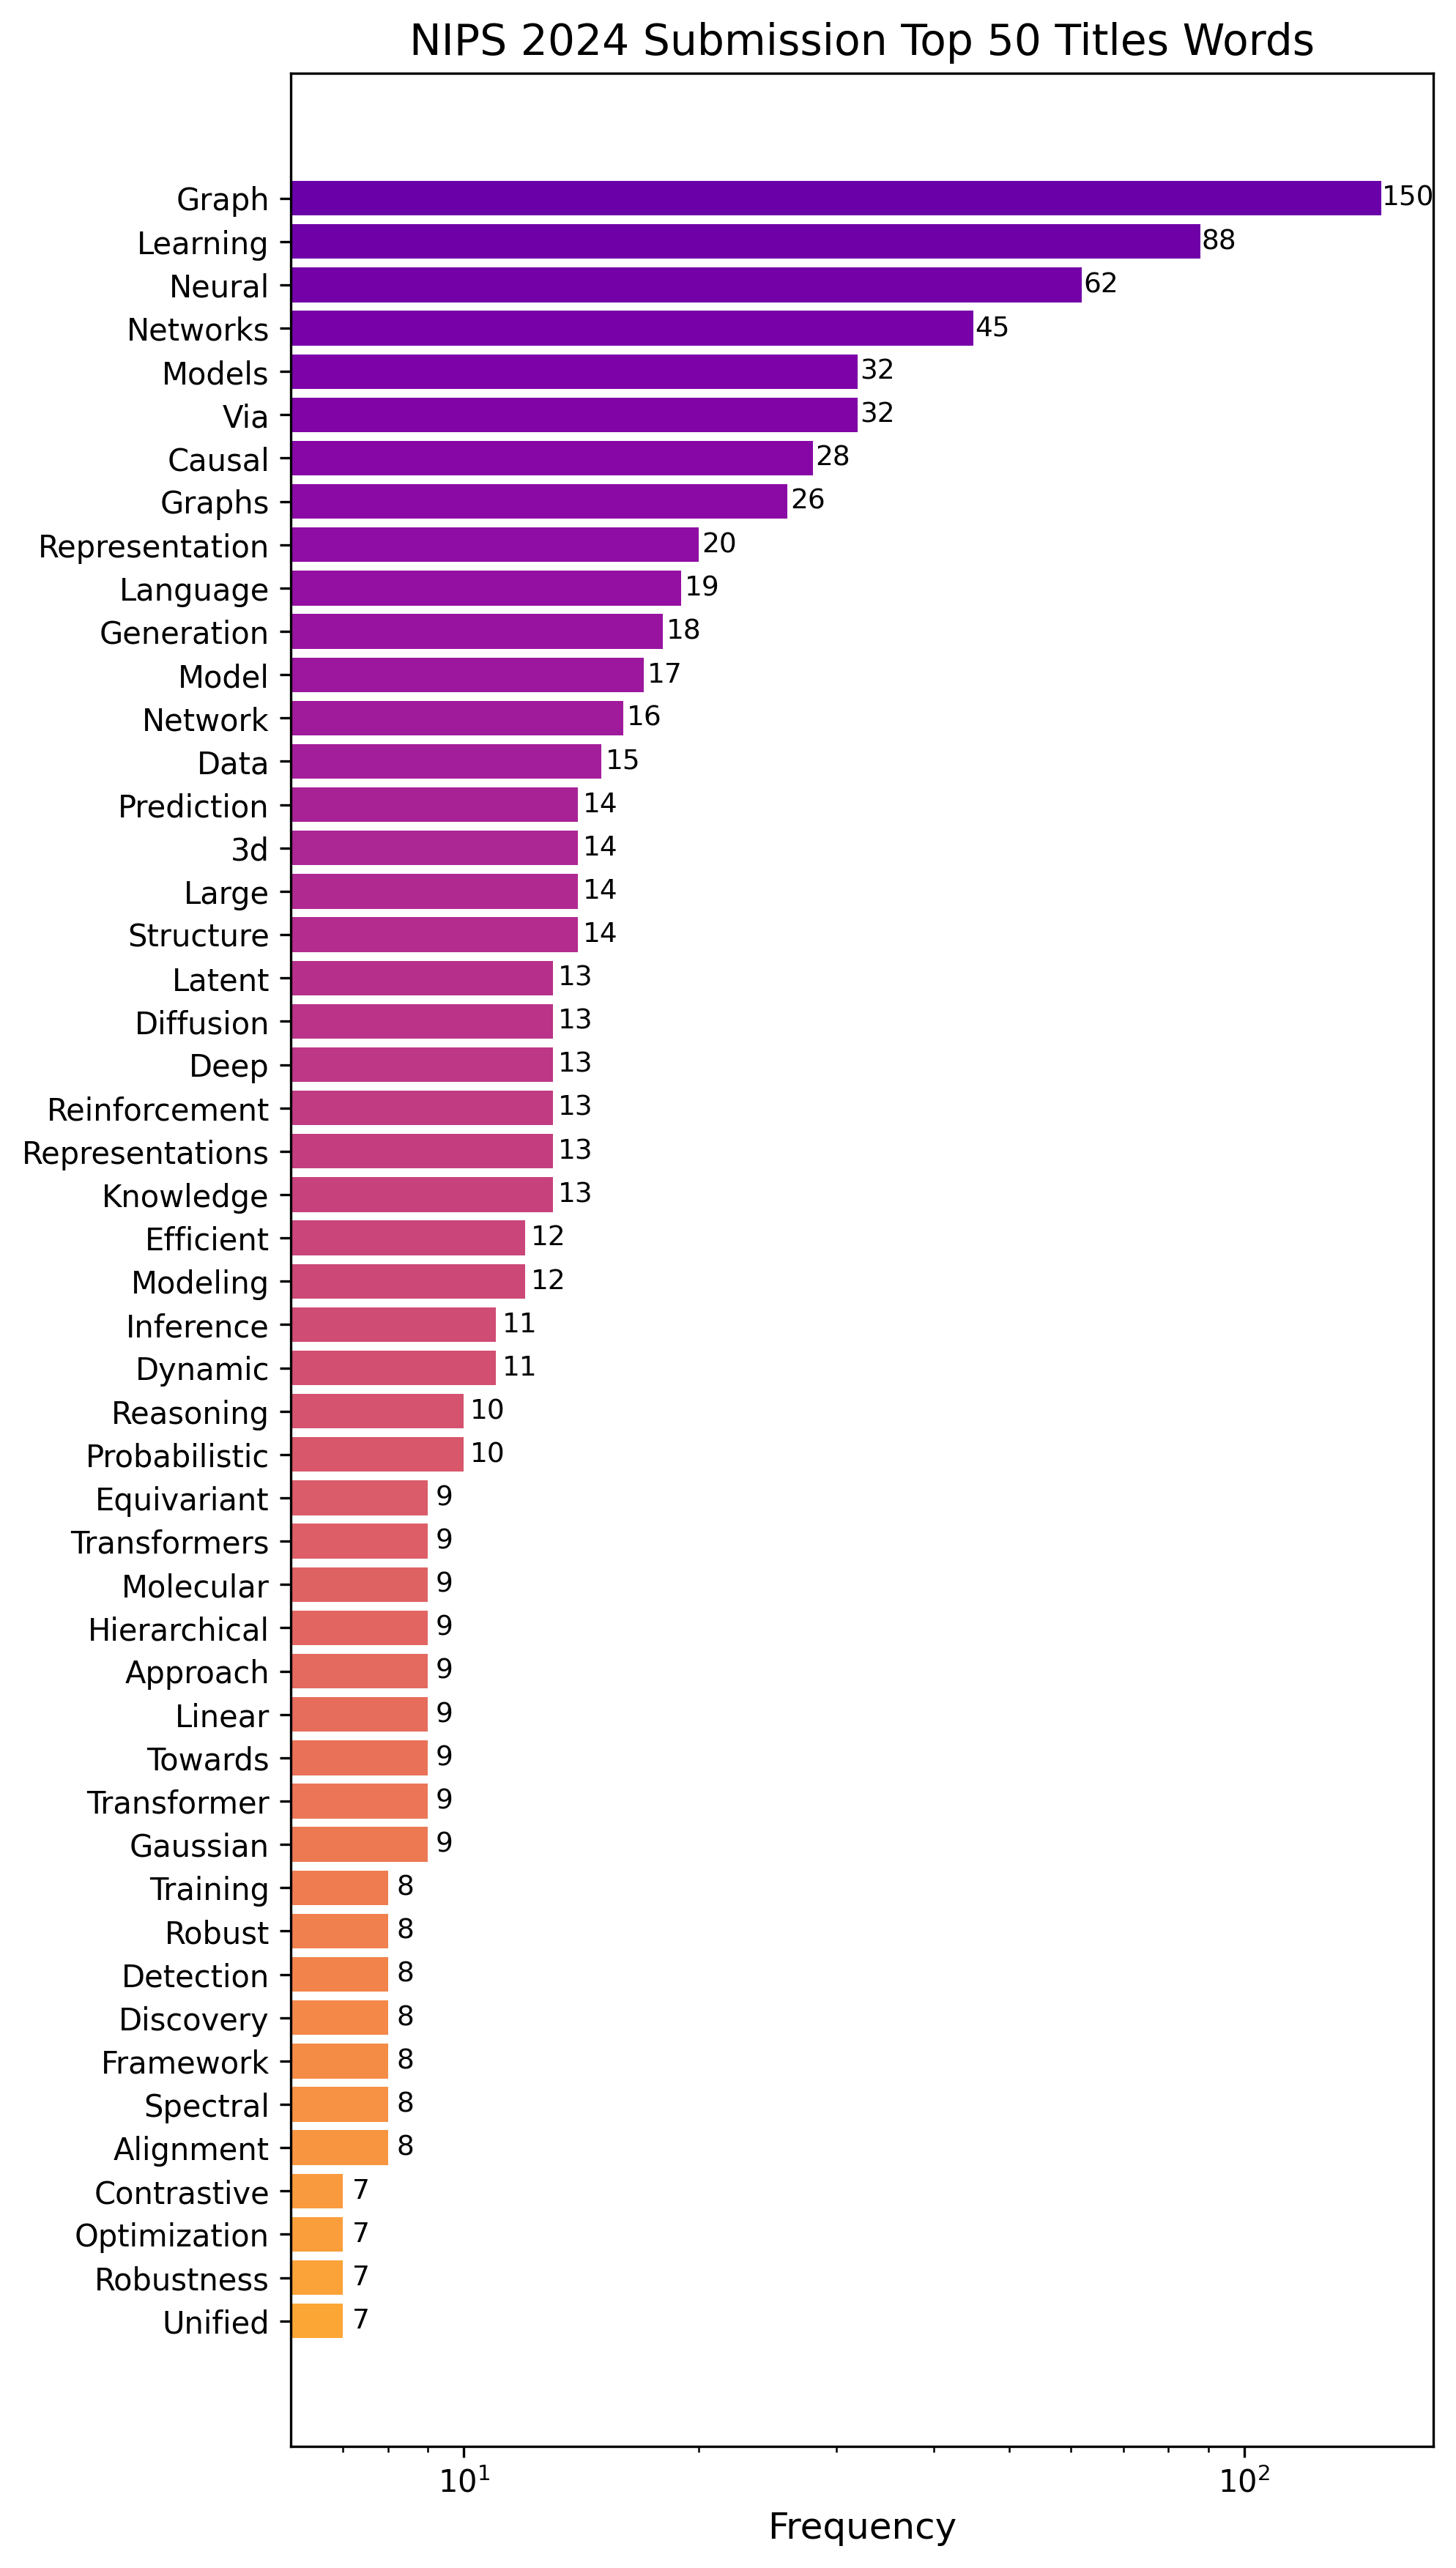

In [61]:
# 显示 N 个最常见关键词和它们的频率
keywords_hist  = Counter(title_words)
num_keyword = 50
keywords_hist_vis = keywords_hist.most_common(num_keyword)

plt.rcdefaults()
fig, ax = plt.subplots(figsize=(8, 12), dpi=300)

# 数据准备
key = [k[0] for k in keywords_hist_vis]
value = [k[1] for k in keywords_hist_vis]
y_pos = np.arange(len(key))

# 使用 cool colormap 渐变颜色
colors = cm.plasma(np.linspace(0.2, 0.8, len(key)))  # 渐变色

# 绘制水平条形图
bars = ax.barh(y_pos, value, align='center', color=colors, ecolor='black', log=True)
ax.set_yticks(y_pos)
ax.set_yticklabels(key, rotation=0, fontsize=10)
ax.invert_yaxis()  # 反转 Y 轴

# 为每个条形添加文本标签
for i, (bar, v) in enumerate(zip(bars, value)):
    text_position = bar.get_width() - 5  # 文字的水平位置
    ax.text(bar.get_width() + 0.2, i, str(v), color='black', ha='left', va='center', fontsize=9)

# 添加标题和标签
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('NIPS 2024 Submission Top {} Titles Words'.format(num_keyword), fontsize=14)

# 调整布局，确保所有内容显示完整
plt.tight_layout()
plt.subplots_adjust(left=0.3, right=0.95, top=0.95, bottom=0.05)  # 手动调整边距

# 显示和保存图形
plt.show()
fig.savefig(f'{path}/assets/graph_titles_frequency.png', dpi=300, bbox_inches='tight')

## 词云

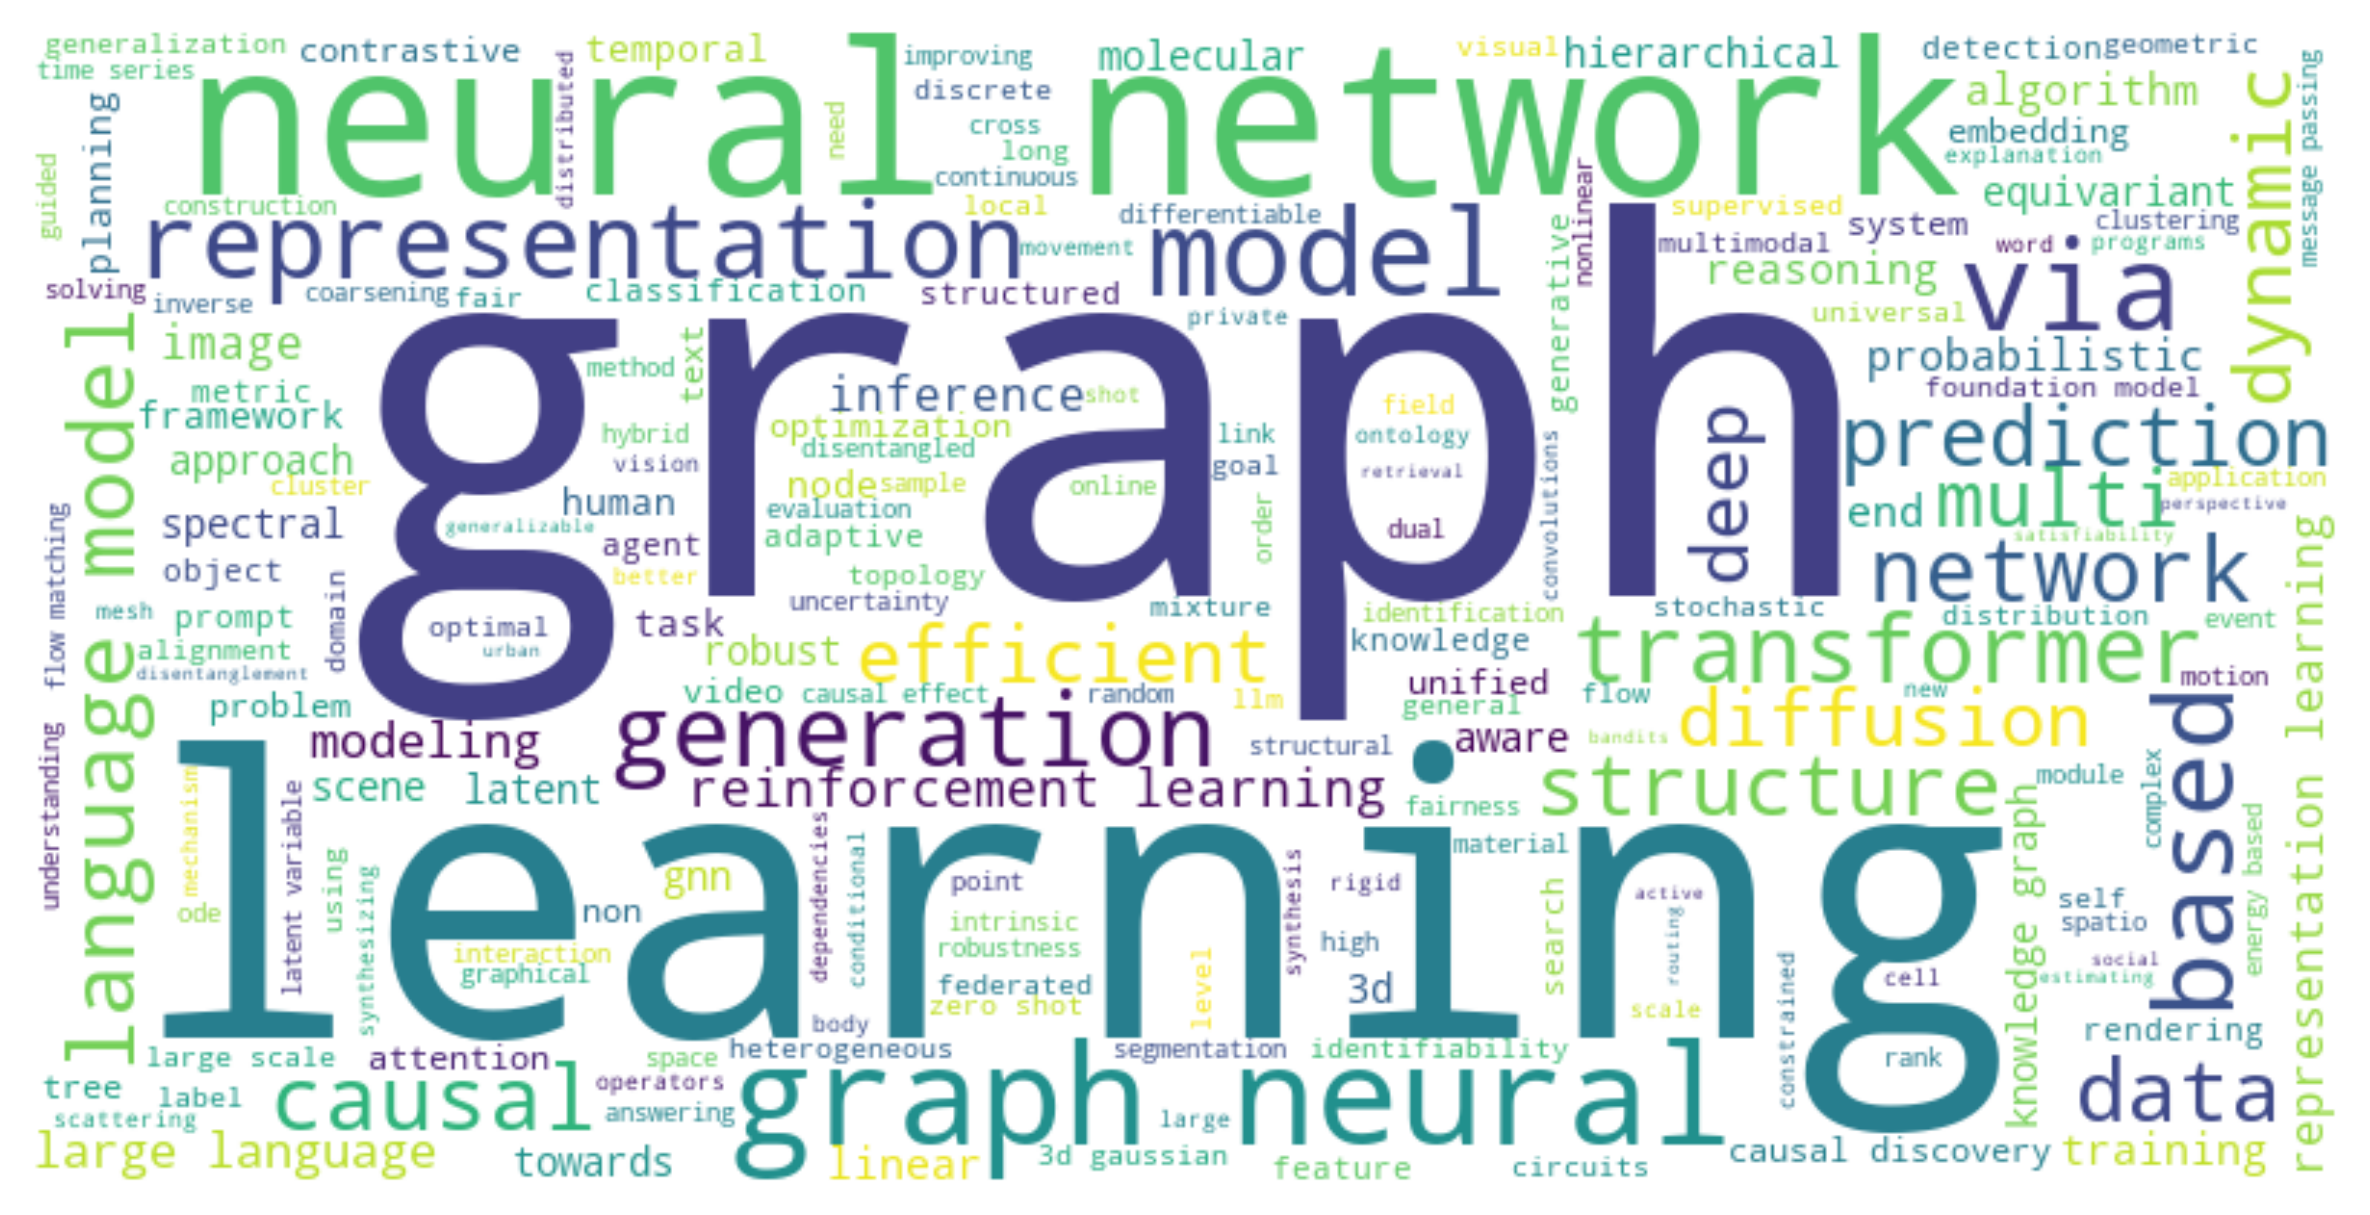

In [57]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(title_words))

# 显示词云
plt.figure(figsize=(10, 5),dpi=300)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # 关闭坐标轴
plt.savefig(f'{path}/assets/graph_titles_frequency_wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()